# 1 - Introdução e Entendimento Inicial

### 1.1 - Objetivo da análise

Esta análise visa identificar padrões e variáveis determinantes para o desenvolvimento de quadros depressivos em estudantes, fornecendo suporte para a construção de um modelo de classificação binária (0: sem depressão, 1: com depressão).

## 1.2 - Contexto do dataset

O dataset utilizado nesse projeto contém informações relacionadas a depressão em estudantes. A partir desses dados, pretende-se analisar padrões e características que possam contribuir para o desenvolvimento de um modelo de Machine Learning que deve responder a seguinte pergunta: Quais fatores aumentam a chance de depressão em estudantes?

**Tema do dataset:** Student Depression Dataset

**Fonte dos dados:** Kaggle

## 1.3 - Entendimento Inicial dos Dados

Nesta etapa, foram importadas as bibliotecas necessárias, realizado o carregamento do dataset e visualizadas as primeiras linhas dos dados, com o objetivo de verificar se a importação ocorreu corretamente e sem problemas de formatação.
- O dataset possui **27.901** registros e **18** variáveis, sendo **17 features** e **1 variável alvo** (Depression).
- O problema é de Classificação Binária Supervisionada, onde:

    0 = Sem depressão

    1 = Com depressão
- A variável alvo apresenta uma distribuição relativamente equilibrada:

    58,5% dos estudantes possuem depressão;
    
    41,5% não possuem depressão.
- A idade dos participantes varia entre 18 e 59 anos, com média de aproximadamente **25,8 anos**.
- O desempenho acadêmico (CGPA) apresenta **média de 7,66**.
- A coluna id possui valores únicos para todos os registros.
- Algumas variáveis apresentam **baixa variabilidade**, como Work Pressure e Job Satisfaction.

In [59]:
# importação das bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

!pip install missingno
import missingno as msno

# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [60]:
# Set the path to the file you'd like to load
file_path = "Student Depression Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "hopesb/student-depression-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_467/2842799218.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-depression-dataset' dataset.


In [61]:
# visualização inicial dos dados

print('HEAD\n')
print(df.head())

print('\n\nTAIL\n')
print(df.tail())

print('\n\nSAMPLE\n')
df.sample(5)

HEAD

   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3       

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
24611,124016,Female,24.0,Meerut,Student,3.0,0.0,8.58,1.0,0.0,Less than 5 hours,Unhealthy,BHM,No,12.0,2.0,Yes,1
26302,132628,Female,33.0,Pune,Student,3.0,0.0,7.72,4.0,0.0,Less than 5 hours,Moderate,PhD,Yes,6.0,5.0,Yes,1
23153,116764,Female,24.0,Surat,Student,1.0,0.0,9.01,2.0,0.0,7-8 hours,Healthy,B.Pharm,No,5.0,2.0,Yes,0
16828,85165,Female,34.0,Kolkata,Student,5.0,0.0,8.04,5.0,0.0,7-8 hours,Moderate,BE,Yes,12.0,4.0,Yes,1
15582,78648,Male,23.0,Vasai-Virar,Student,3.0,0.0,7.47,3.0,0.0,5-6 hours,Moderate,BA,Yes,10.0,5.0,Yes,1


In [62]:
# tamanho do dataset

print(f'tamanho: {df.shape}')
print(f'o dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas')

# informações gerais

print('\nnome das colunas:')
list(df.columns)

tamanho: (27901, 18)
o dataset possui 27901 linhas e 18 colunas

nome das colunas:


['id',
 'Gender',
 'Age',
 'City',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

In [63]:
# tipos dos dados
print('\ntipos dos dados:')
print(df.dtypes)


tipos dos dados:
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object


In [64]:
# valores unicos por coluna

print('valores unicos por coluna:')
print(df.nunique().sort_values())

valores unicos por coluna:
Gender                                       2
Have you ever had suicidal thoughts ?        2
Depression                                   2
Family History of Mental Illness             2
Work Pressure                                3
Dietary Habits                               4
Job Satisfaction                             5
Sleep Duration                               5
Financial Stress                             5
Academic Pressure                            6
Study Satisfaction                           6
Work/Study Hours                            13
Profession                                  14
Degree                                      28
Age                                         34
City                                        52
CGPA                                       332
id                                       27901
dtype: int64


In [65]:
# verificação da variavel alvo

target = "Depression"

X = df.drop(columns=[target])
y = df[target]

print(f"variável alvo: {target}")
print(f"número de features: {X.shape[1]}")

print('\n\nHEAD\n')
print(df[target].head())

print('\n\nTAIL\n')
print(df[target].tail())

# como problema classificação

print(f'\n\n{df[target].value_counts(normalize=True) * 100}')

variável alvo: Depression
número de features: 17


HEAD

0    1
1    0
2    0
3    1
4    0
Name: Depression, dtype: int64


TAIL

27896    0
27897    0
27898    0
27899    1
27900    1
Name: Depression, dtype: int64


Depression
1    58.549873
0    41.450127
Name: proportion, dtype: float64


## 1.4 - Classificação das variáveis

Ao analisar a saída referente à coluna do dataset, as variáveis foram classificadas em númericas, categóricas, identificadoras e variável alvo. Não foram identificadas variáveis temporais, uma vez que o conjunto de dados não possui colunas relacionadas a datas ou horários. Também não foram encontradas variáveis textuais livres, sendo todas as variáveis categóricas compostas por categorias pré-definidas.

In [66]:
# separação inicial por tipo de variável

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns


### 1.4.1 - Variáveis numéricas

In [67]:
print('variáveis numéricas:')
print(list(num_cols))

variáveis numéricas:
['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']


In [68]:
# resumo estatistico das variáveis numéricas

print('resumo')
print(df.describe())

resumo
                  id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27901.000000        27901.000000      27901.000000      27901.000000   
mean       7.656104            2.943837          0.000681          7.156984   
std        1.470707            1.361148          0.044394          3.707642   
min        0.000000         

In [69]:
# variaveis numericas contínuas
num_continuas = [
    'Age',
    'CGPA',
    'Work/Study Hours'
]

# variáveis numéricas ordinais
num_ordinais = [
    'Academic Pressure',
    'Work Pressure',
    'Study Satisfaction',
    'Job Satisfaction',
    'Financial Stress'
]

print('variaveis numericas continuas\n:')
print(df[num_continuas].describe())
for col in num_ordinais:
    print(f"\n{col}")
    print(sorted(df[col].unique()))

print('\n\nvariaveis numericas ordinais\n:')
print(df[num_ordinais].describe())

variaveis numericas continuas
:
                Age          CGPA  Work/Study Hours
count  27901.000000  27901.000000      27901.000000
mean      25.822300      7.656104          7.156984
std        4.905687      1.470707          3.707642
min       18.000000      0.000000          0.000000
25%       21.000000      6.290000          4.000000
50%       25.000000      7.770000          8.000000
75%       30.000000      8.920000         10.000000
max       59.000000     10.000000         12.000000

Academic Pressure
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

Work Pressure
[np.float64(0.0), np.float64(2.0), np.float64(5.0)]

Study Satisfaction
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

Job Satisfaction
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Financial Stress
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0

### 1.4.2 - Variáveis categóricas

In [70]:
print('variáveis categóricas:')
print(list(cat_cols))

variáveis categóricas:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [71]:
# resumo estatistico das variáveis categóricas

print('resumo')
print(df.describe(include='object'))

resumo
       Gender    City Profession     Sleep Duration Dietary Habits    Degree  \
count   27901   27901      27901              27901          27901     27901   
unique      2      52         14                  5              4        28   
top      Male  Kalyan    Student  Less than 5 hours      Unhealthy  Class 12   
freq    15547    1570      27870               8310          10317      6080   

       Have you ever had suicidal thoughts ? Family History of Mental Illness  
count                                  27901                            27901  
unique                                     2                                2  
top                                      Yes                               No  
freq                                   17656                            14398  


### 1.4.3 - Variáveis identificadoras

In [72]:
# variavel identificadora

print(df['id'].describe())
print(f"quantidade de registros: {len(df)}")
print(f"IDs únicos: {df['id'].nunique()}")
print(f"possui IDs repetidos? {df['id'].nunique() != len(df)}")

count     27901.000000
mean      70442.149421
std       40641.175216
min           2.000000
25%       35039.000000
50%       70684.000000
75%      105818.000000
max      140699.000000
Name: id, dtype: float64
quantidade de registros: 27901
IDs únicos: 27901
possui IDs repetidos? False


## 1.5 - Tabela Resumo

In [73]:
# tabela resumo

resumo_variaveis = pd.DataFrame({
    "variavel": df.columns,
    "tipo_pandas": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique().values,
    "percentual_unicos": (df.nunique().values / len(df) * 100).round(2),
    "missing": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean().values * 100).round(2)
})

print(resumo_variaveis)

                                 variavel tipo_pandas  valores_unicos  \
0                                      id       int64           27901   
1                                  Gender      object               2   
2                                     Age     float64              34   
3                                    City      object              52   
4                              Profession      object              14   
5                       Academic Pressure     float64               6   
6                           Work Pressure     float64               3   
7                                    CGPA     float64             332   
8                      Study Satisfaction     float64               6   
9                        Job Satisfaction     float64               5   
10                         Sleep Duration      object               5   
11                         Dietary Habits      object               4   
12                                 Degree      obje

## 2. Qualidade e Tratamento de Dados

Esta etapa focou na integridade do *dataset*, visando mitigar ruídos que comprometam a performance do modelo preditivo. O processo foi estruturado em três eixos:

1. **Identificação de *Missing Values*:** Mapeamento de lacunas para definição de políticas de imputação ou descarte.
2. **Detecção de Duplicatas:** Eliminação de registros redundantes para evitar o enviesamento do treinamento.
3. **Validação de Consistência Lógica:** Verificação de *outliers* estruturais, como faixas etárias fora do espectro acadêmico ou valores de CGPA fora da escala nominal.

A integridade do dataset apresenta alta qualidade, com volume de dados faltantes estatisticamente irrelevante.

  - Magnitude: Foram identificados apenas 3 valores nulos em um conjunto de 27.901 registros, correspondendo a aproximadamente 0,01% do total.

  - Distribuição: A ausência é restrita à variável Financial Stress (IDs 68910, 97610 e 22377). As demais 16 variáveis encontram-se 100% preenchidas.

  - Diagnóstico: A natureza pontual e isolada das falhas indica erros aleatórios de coleta (Missing Completely at Random - MCAR), descartando comprometimento estrutural do sistema de aquisição.

In [74]:
# valores ausentes

print(df.isnull().sum())

print('\n\npercentual de valores ausentes:')
print((df.isnull().mean() * 100).sort_values(ascending=False))

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64


percentual de valores ausentes:
Financial Stress                         0.010752
id                                       0.000000
Gender                                   0.000000
Age                          

In [75]:
# tabela resumo

missing_values = pd.DataFrame({
    "variavel": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean().values * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="missing_percent",
    ascending=False
)

print(missing_values)

                                 variavel  missing_count  missing_percent
15                       Financial Stress              3             0.01
0                                      id              0             0.00
1                                  Gender              0             0.00
2                                     Age              0             0.00
4                              Profession              0             0.00
3                                    City              0             0.00
6                           Work Pressure              0             0.00
7                                    CGPA              0             0.00
8                      Study Satisfaction              0             0.00
5                       Academic Pressure              0             0.00
9                        Job Satisfaction              0             0.00
10                         Sleep Duration              0             0.00
12                                 Deg

In [76]:
total_missing = df.isnull().sum().sum()

print(f"Total de valores ausentes no dataset: {total_missing}")

Total de valores ausentes no dataset: 3


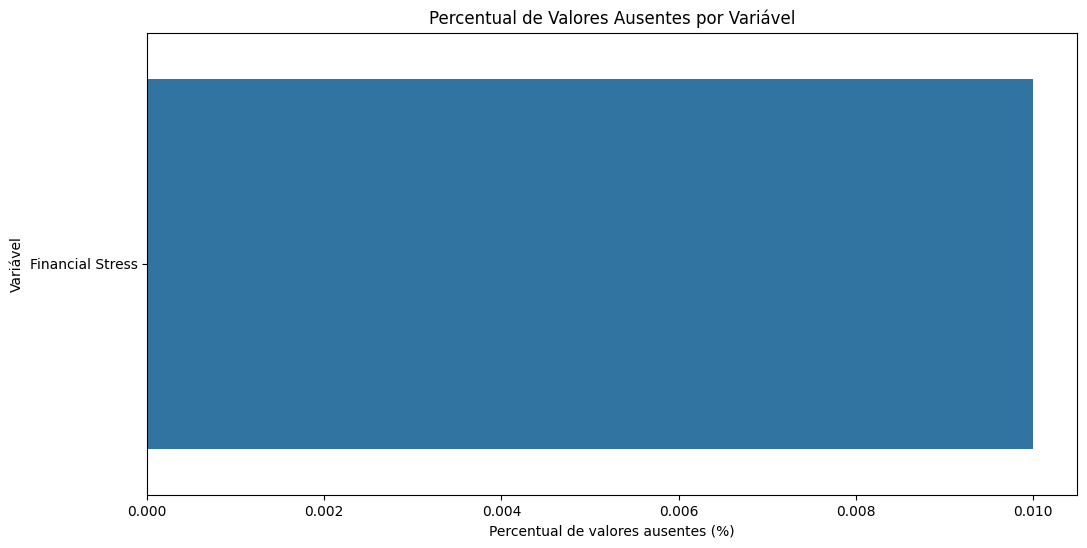

In [77]:
missing_values_plot = missing_values[missing_values["missing_count"] > 0]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=missing_values_plot,
    x="missing_percent",
    y="variavel"
)
plt.title("Percentual de Valores Ausentes por Variável")
plt.xlabel("Percentual de valores ausentes (%)")
plt.ylabel("Variável")
plt.show()

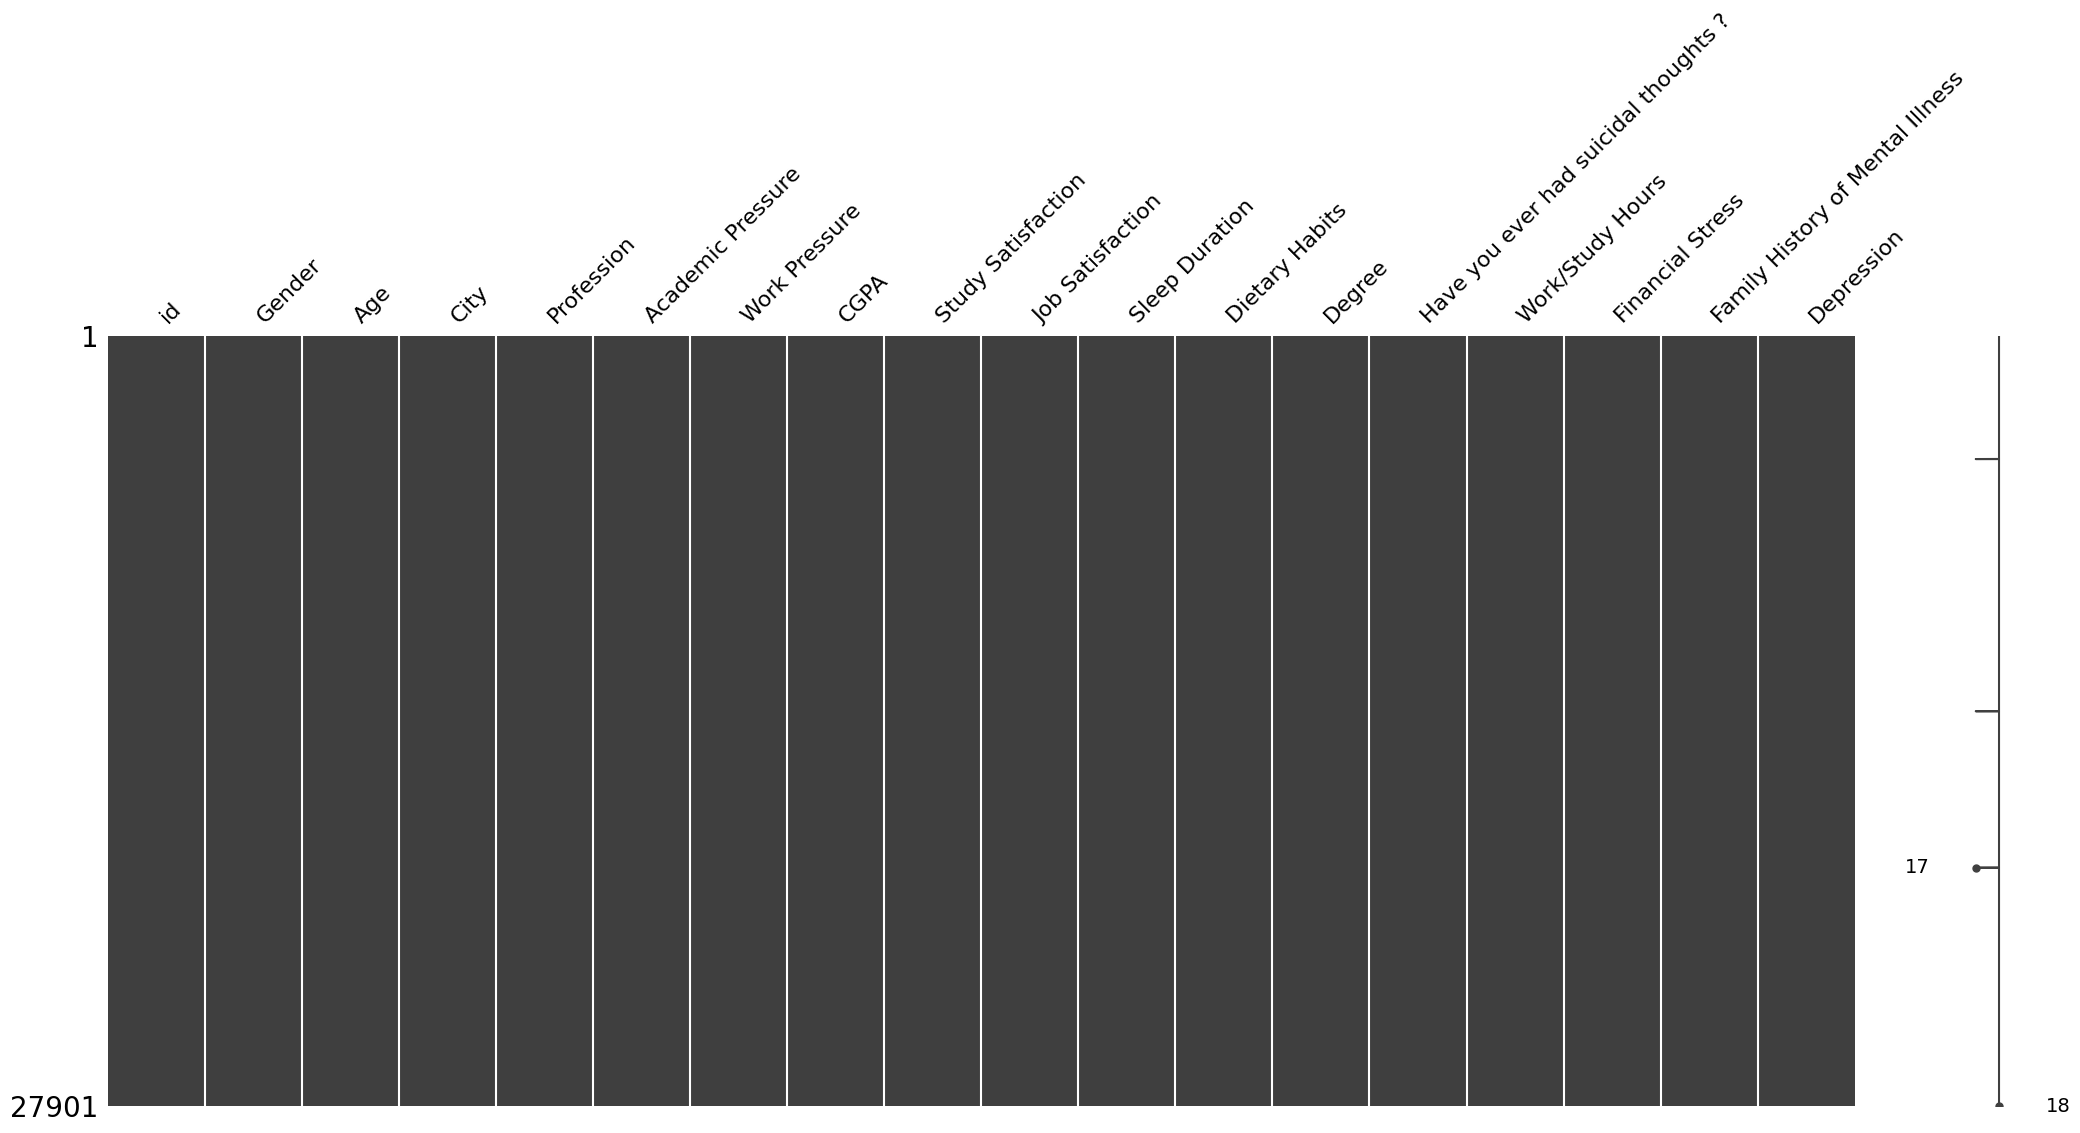

In [78]:
# matriz de ausencia
msno.matrix(df)
plt.show()

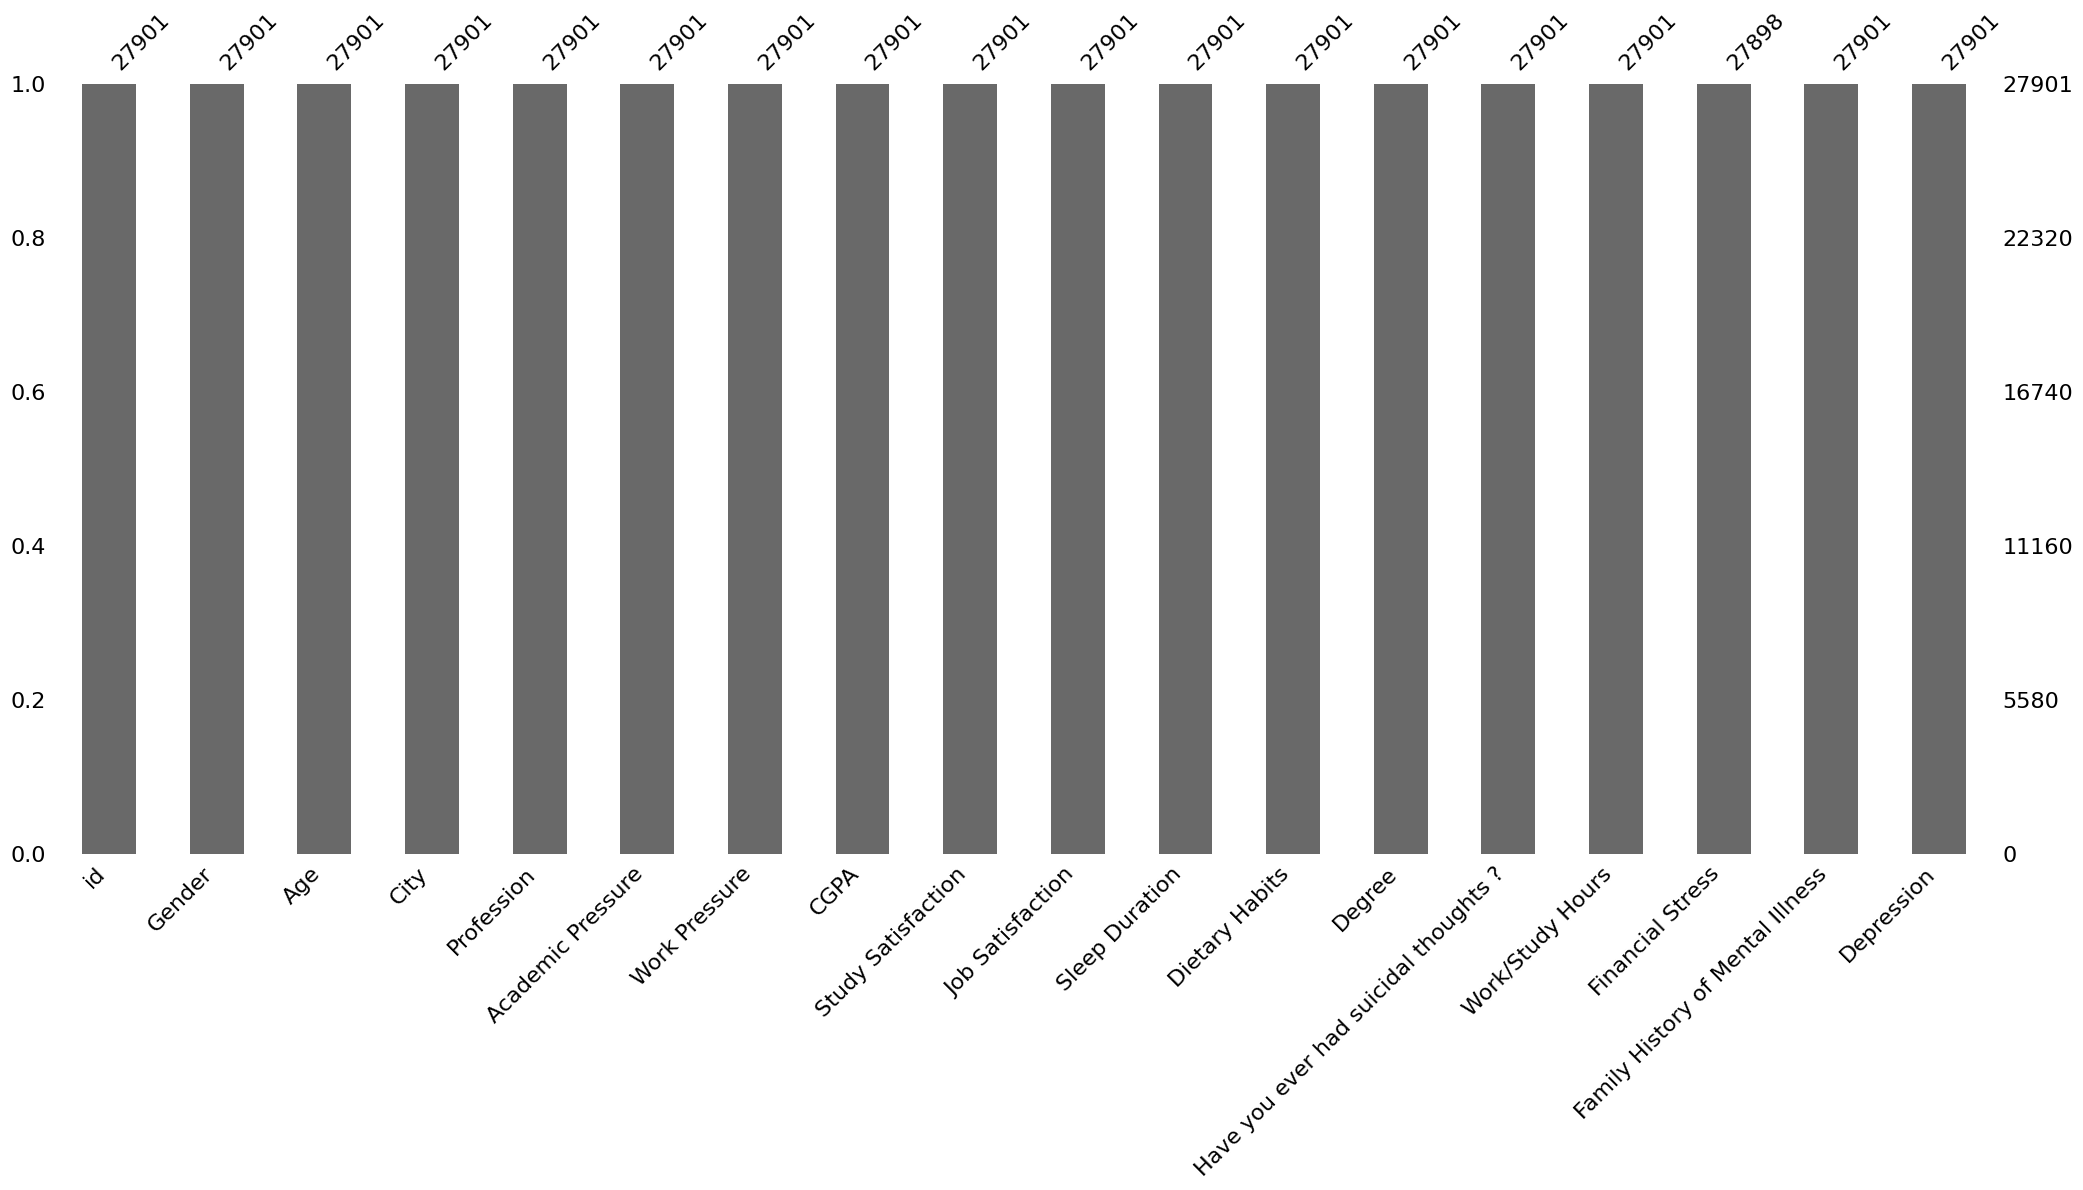

In [79]:
# grafico de barras
msno.bar(df)
plt.show()

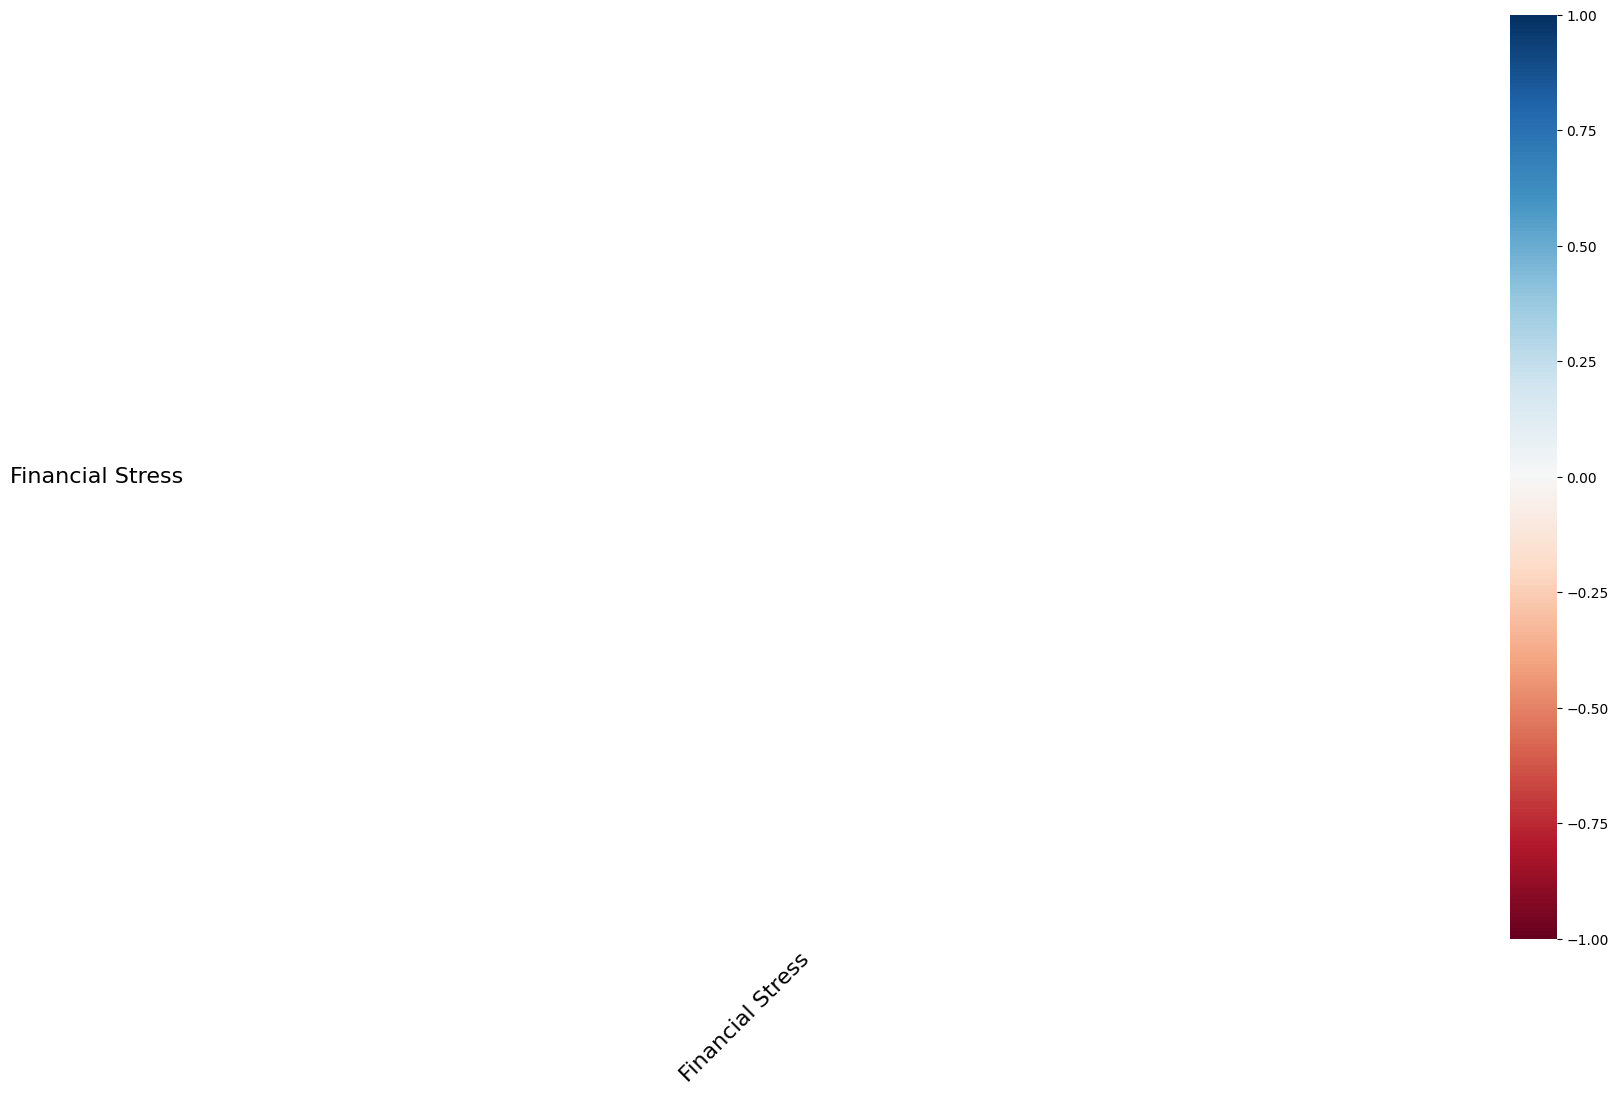

In [80]:
# mapa correlação entre ausnencias
msno.heatmap(df)
plt.show()

In [81]:
missing_por_linha = df.isnull().sum(axis=1)

print(missing_por_linha.describe())

print('\n')
print(df.loc[missing_por_linha.sort_values(ascending=False).head(10).index])

percent_missing_linha = df.isnull().mean(axis=1) * 100

print('\n')
print(percent_missing_linha.describe())

count    27901.000000
mean         0.000108
std          0.010369
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
dtype: float64


          id  Gender   Age           City Profession  Academic Pressure  \
13596  68910    Male  29.0      Hyderabad    Student                2.0   
19266  97610  Female  20.0        Kolkata    Student                1.0   
4458   22377  Female  32.0       Varanasi    Student                3.0   
18610  94270    Male  26.0         Mumbai    Student                3.0   
18609  94256  Female  24.0         Jaipur    Student                2.0   
18608  94236    Male  26.0          Thane    Student                3.0   
18607  94235    Male  29.0           Pune    Student                3.0   
18606  94234  Female  33.0       Srinagar    Student                5.0   
18605  94231  Female  25.0  Visakhapatnam    Student                2.0   
18604  94230  Female  24.0          Surat    Student     

## 2.2 - Análise de duplicatas



In [82]:
# Verificação real de alunos com respostas 100% idênticas
duplicatas_reais = df.drop(columns=['id']).duplicated().sum() # IGNORA O ID POIS ELE SEMPRE FORÇA A LINHA A SER DIFERENTE DA OUTRA
print(f"Alunos com perfis exatamente iguais: {duplicatas_reais}")

Alunos com perfis exatamente iguais: 0


## 2.3 - Análise de Inconsistências

Após a verificação dos limites lógicos e da cardinalidade das variáveis categóricas, foi constatado que o dataset necessita de limpeza em colunas específicas:

* **Problema na Coluna "City":** Esta variável contém inconsistência na coleta de dados. Identificamos:
    * **Entradas sem sentido ou valores de outras colunas misturados**
    * **Erros de digitação**
    * **Entradas que parecem nomes de pessoas em vez de cidades**
    
* **Forte Desbalanceamento em "Profession":** O dataset é massivamente composto por Estudantes (27.870 casos), enquanto outras 13 profissões (como Arquiteto, Professor, Chef) somam apenas 31 casos no total. Dado o nome e objetivo do dataset, a presença de não-estudantes é um **ruído**. A estratégia ideal será filtrar o dataframe para manter `Profession == 'Student'` e, em seguida, remover a coluna, pois ela passará a ter apenas um valor único e não ajudará o modelo.

In [83]:
# valores unicos por coluna

for col in df.columns:
    print(f"\nColuna: {col}")
    print(f"Tipo: {df[col].dtype}")
    print(f"Valores únicos: {df[col].nunique()}")
    print(df[col].dropna().unique()[:20])
    print("-" * 50)


Coluna: id
Tipo: int64
Valores únicos: 27901
[  2   8  26  30  32  33  52  56  59  62  83  91  94 100 103 106 120 132
 139 145]
--------------------------------------------------

Coluna: Gender
Tipo: object
Valores únicos: 2
['Male' 'Female']
--------------------------------------------------

Coluna: Age
Tipo: float64
Valores únicos: 34
[33. 24. 31. 28. 25. 29. 30. 27. 19. 20. 23. 18. 21. 22. 34. 32. 26. 39.
 35. 42.]
--------------------------------------------------

Coluna: City
Tipo: object
Valores únicos: 52
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana']
--------------------------------------------------

Coluna: Profession
Tipo: object
Valores únicos: 14
['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entre

In [84]:
# colunas com alta cardinalidade

cardinalidade = pd.DataFrame({
    "variavel": df.columns,
    "valores_unicos": df.nunique().values,
    "percentual_unicos": (df.nunique().values / len(df) * 100).round(2)
}).sort_values(by="percentual_unicos", ascending=False)

print(cardinalidade)

print('\n')
alta_cardinalidade = cardinalidade[cardinalidade["percentual_unicos"] > 50]

print(alta_cardinalidade)

                                 variavel  valores_unicos  percentual_unicos
0                                      id           27901             100.00
7                                    CGPA             332               1.19
3                                    City              52               0.19
2                                     Age              34               0.12
12                                 Degree              28               0.10
14                       Work/Study Hours              13               0.05
4                              Profession              14               0.05
15                       Financial Stress               5               0.02
5                       Academic Pressure               6               0.02
8                      Study Satisfaction               6               0.02
10                         Sleep Duration               5               0.02
9                        Job Satisfaction               5               0.02

### 2.3.1 - Valores impossíveis

In [85]:
print(df[(df['Age'] < 0) | (df['Age'] > 100)])

print('\n')
print(df[(df['CGPA'] < 0) | (df['CGPA'] > 10)])

print('\n')
print(df[
    ~df['Academic Pressure'].isin([1,2,3,4,5])
])

print('\n')
print(sorted(df['Study Satisfaction'].dropna().unique()))

print('\n')
print(sorted(df['Job Satisfaction'].dropna().unique()))

print('\n')
print(sorted(df['Financial Stress'].dropna().unique()))

print('\n')
print(df[(df['Work/Study Hours'] < 0)])

print('\n')
print(df[(df['Work/Study Hours'] > 24)])

print('\n')
print(df['Gender'].value_counts(dropna=False))

print('\n')
print(df['Depression'].value_counts(dropna=False))

print('\n')
print(df['Have you ever had suicidal thoughts ?'].value_counts(dropna=False))

print('\n')
print(df['Family History of Mental Illness'].value_counts(dropna=False))

Empty DataFrame
Columns: [id, Gender, Age, City, Profession, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Work/Study Hours, Financial Stress, Family History of Mental Illness, Depression]
Index: []


Empty DataFrame
Columns: [id, Gender, Age, City, Profession, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Work/Study Hours, Financial Stress, Family History of Mental Illness, Depression]
Index: []


           id  Gender   Age       City Profession  Academic Pressure  \
3501    17549  Female  20.0      Patna    Student                0.0   
4365    21880    Male  38.0    Chennai    Student                0.0   
13909   70453  Female  20.0  Ahmedabad    Student                0.0   
14855   75007    Male  21.0    Lucknow    Student                0.0   
20913  105773   

### 2.3.2 - Erros de digitação

In [86]:
cat_cols = [
    'Gender',
    'City',
    'Profession',
    'Sleep Duration',
    'Dietary Habits',
    'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Depression'
]

for col in cat_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].unique())


Gender
['Male' 'Female']

City
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']

Profession
['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']

Sleep Duration
['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']

Dietary Habits
['Healthy' 'Moderate' 'Unhealthy' 'Others']

Degree
['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' 'Class 12' 'B.Ed' 'LLB' 'BE'
 'M.Ed' 'MSc' 'BHM

### 2.3.3 - Categorias repetidas

In [87]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City
City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   

# 3 - Exploração de Dados (EDA)

Nesta fase central do projeto, foi explorado o comportamento das variáveis para descobrir os padrões ocultos nos dados. Para manter a clareza, estruturamos essa exploração em quatro etapas lógicas:

1. **Visão Individual (Univariada e Distribuições):** Analisar o comportamento isolado de cada característica, mapeando como os dados estão distribuídos e suas frequências.
2. **Visão Cruzada (Bivariada):** Relacionar as variáveis do dataset com o nosso alvo e entre si, permitindo validar hipóteses de negócio.
3. **Visão Global (Multivariada e Correlações):** Mapear as relações matemáticas de todo o conjunto e checar possíveis vazamentos de dados (data leakage).

## 3.1 Visão Individual (Análise Univariada)

### 3.1.1 - Variáveis Numéricas

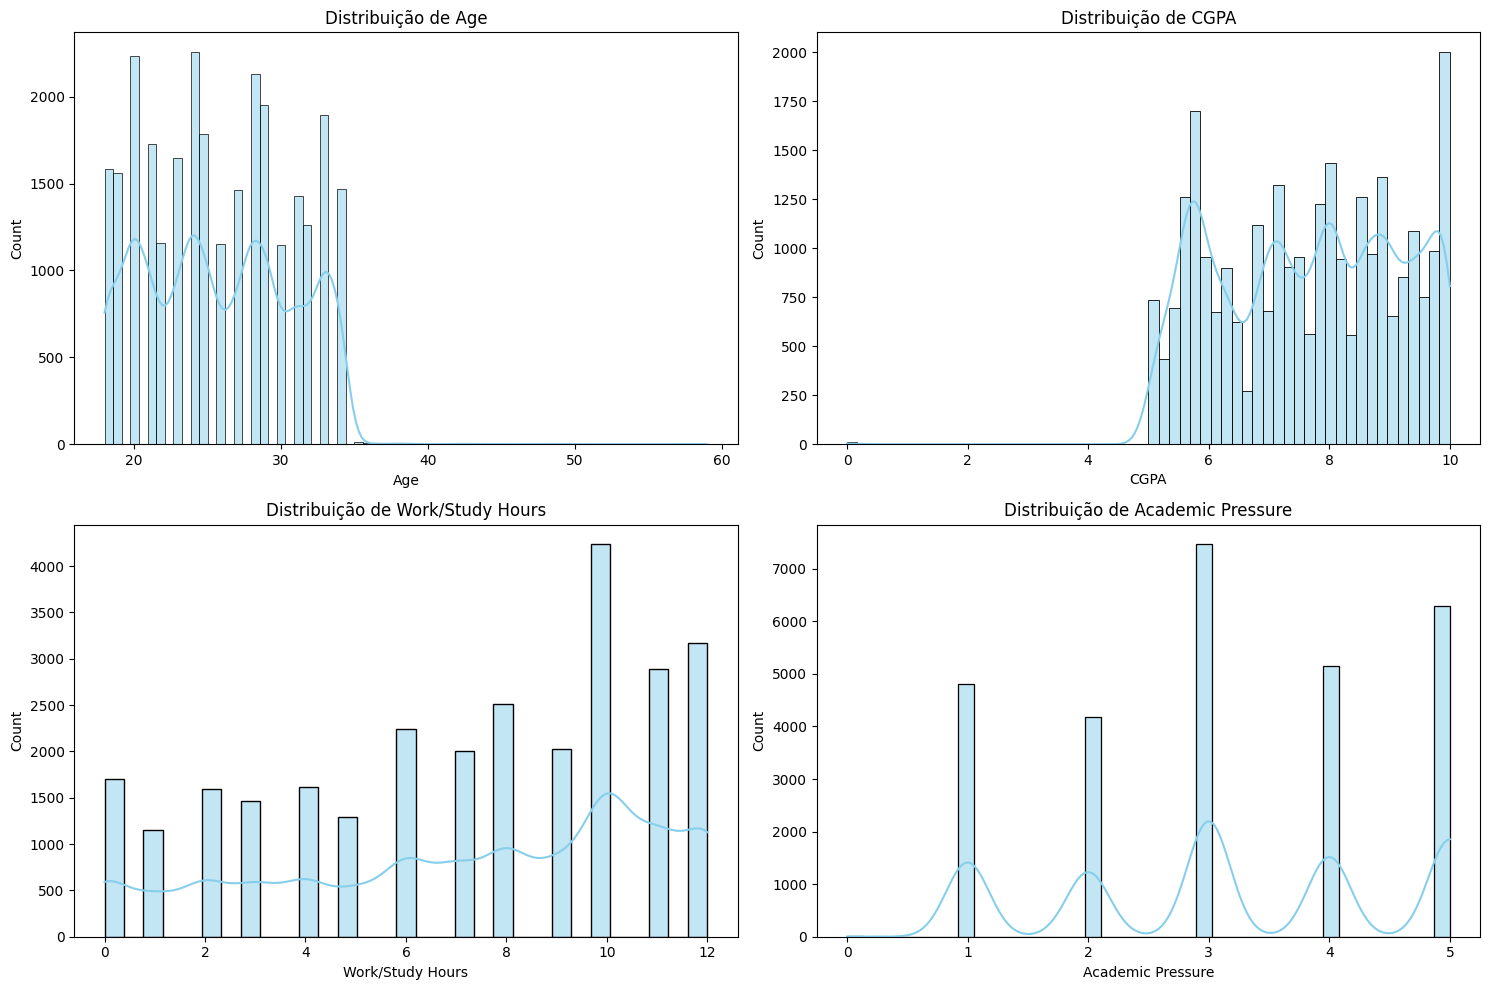

In [88]:
cols_to_plot = ['Age', 'CGPA', 'Work/Study Hours', 'Academic Pressure']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

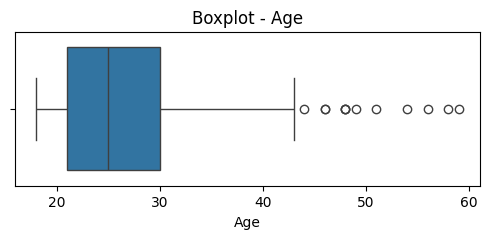

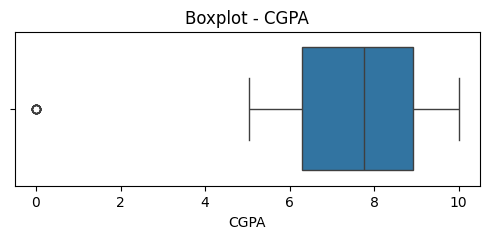

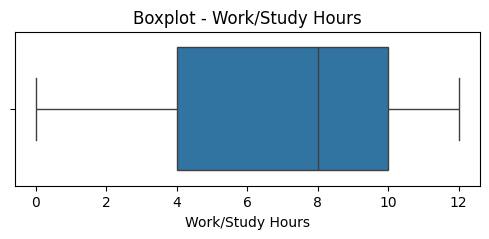

In [89]:
for col in num_continuas:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [90]:
num_ordinais = [
    'Academic Pressure',
    'Work Pressure',
    'Study Satisfaction',
    'Job Satisfaction',
    'Financial Stress'
]

print(df[num_ordinais].describe())

print('\n')
for col in num_ordinais:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())

       Academic Pressure  Work Pressure  Study Satisfaction  Job Satisfaction  \
count       27901.000000   27901.000000        27901.000000      27901.000000   
mean            3.141214       0.000430            2.943837          0.000681   
std             1.381465       0.043992            1.361148          0.044394   
min             0.000000       0.000000            0.000000          0.000000   
25%             2.000000       0.000000            2.000000          0.000000   
50%             3.000000       0.000000            3.000000          0.000000   
75%             4.000000       0.000000            4.000000          0.000000   
max             5.000000       5.000000            5.000000          4.000000   

       Financial Stress  
count      27898.000000  
mean           3.139867  
std            1.437347  
min            1.000000  
25%            2.000000  
50%            3.000000  
75%            4.000000  
max            5.000000  



Academic Pressure
Academic Pressu

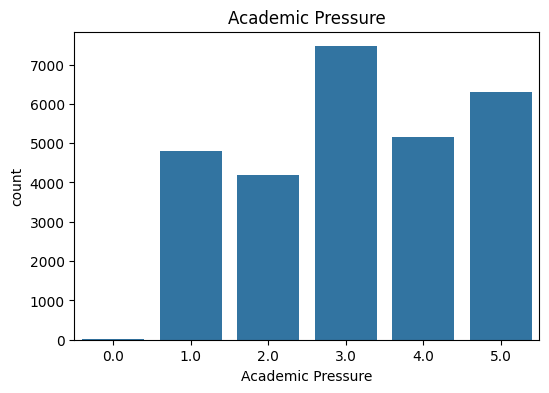

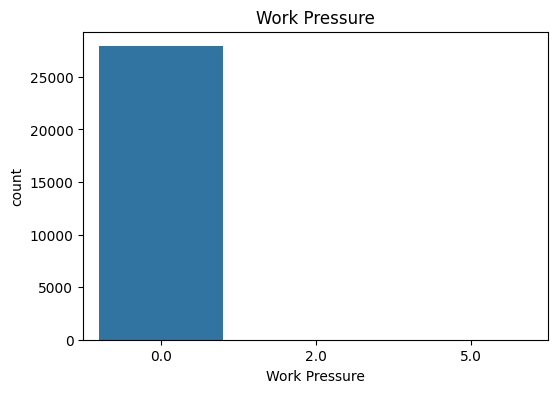

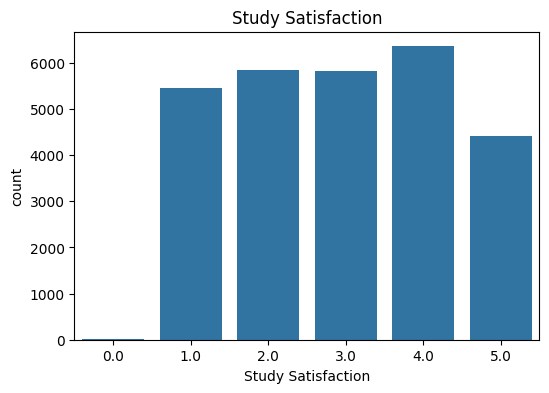

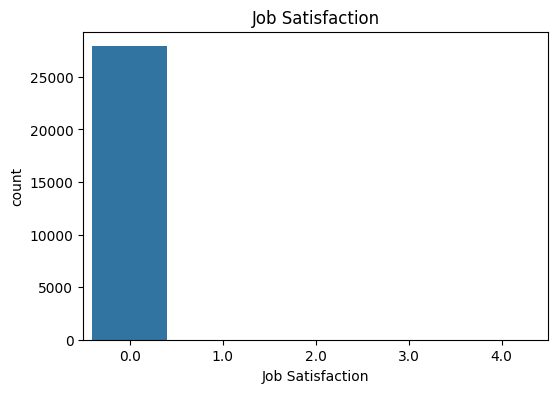

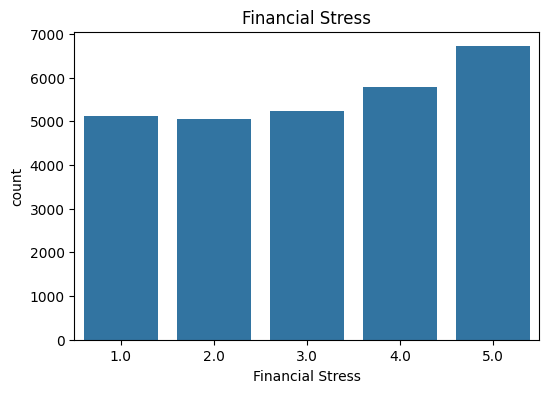

In [91]:
for col in num_ordinais:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        order=sorted(df[col].dropna().unique())
    )

    plt.title(col)
    plt.show()

### 3.1.2 - Variáveis categóricas

In [92]:
cat_cols = [
    'Gender',
    'City',
    'Profession',
    'Sleep Duration',
    'Dietary Habits',
    'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

# frequencia absoluta
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

print('\n')
# frequencia relativa
for col in cat_cols:
    print(f"\n{col}")
    print(
        round(
            df[col].value_counts(normalize=True) * 100,
            2
        )
    )


Gender
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City
City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   

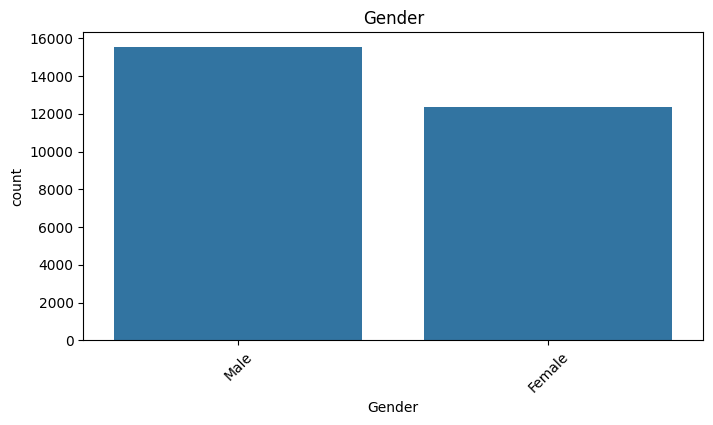

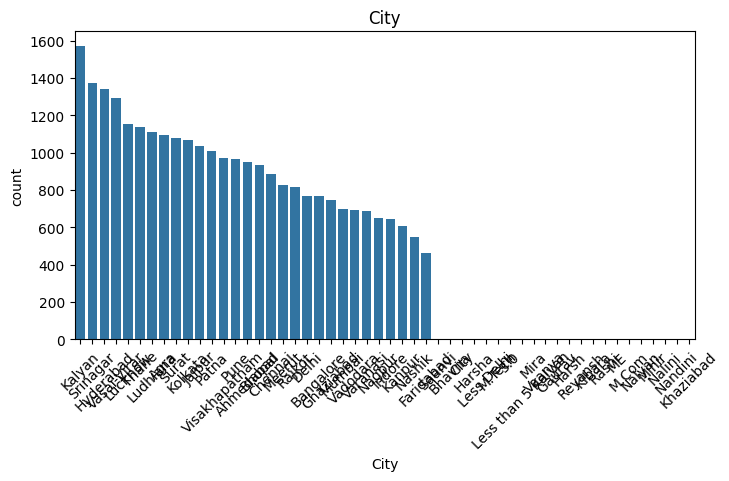

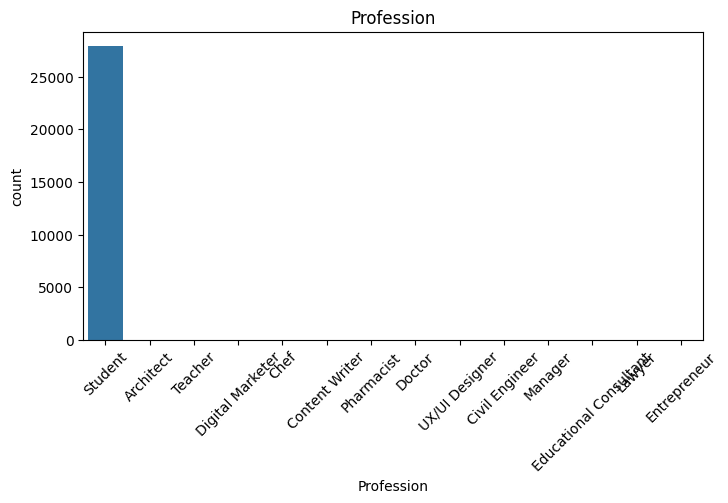

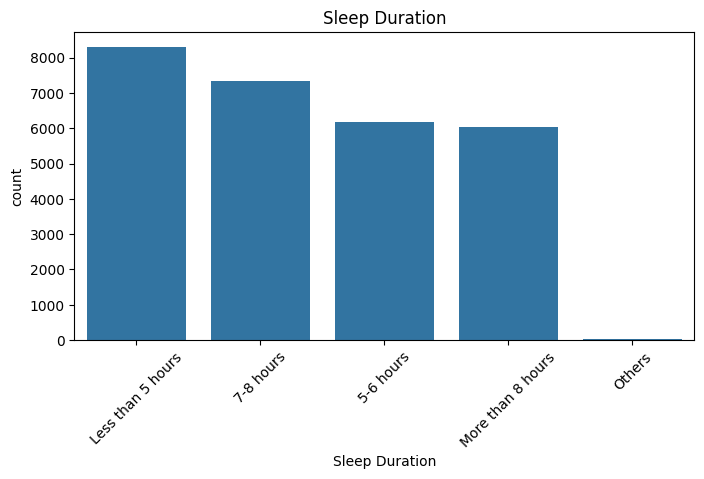

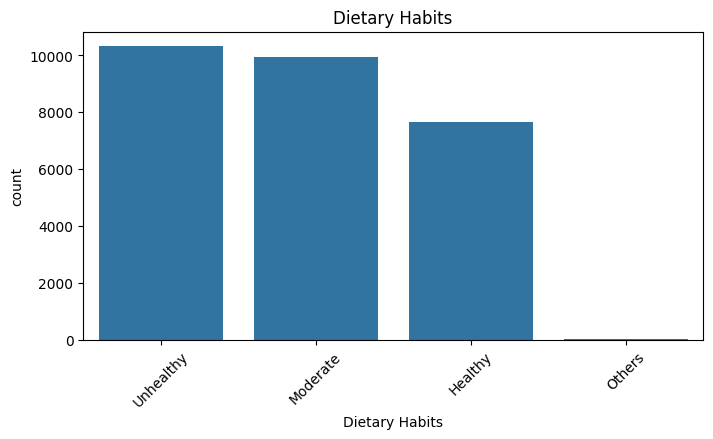

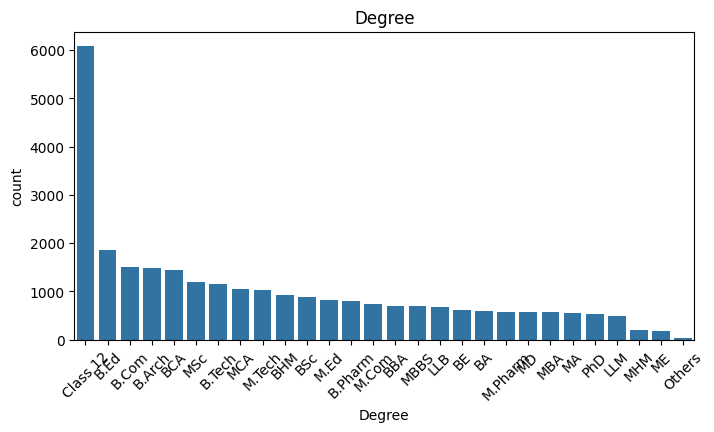

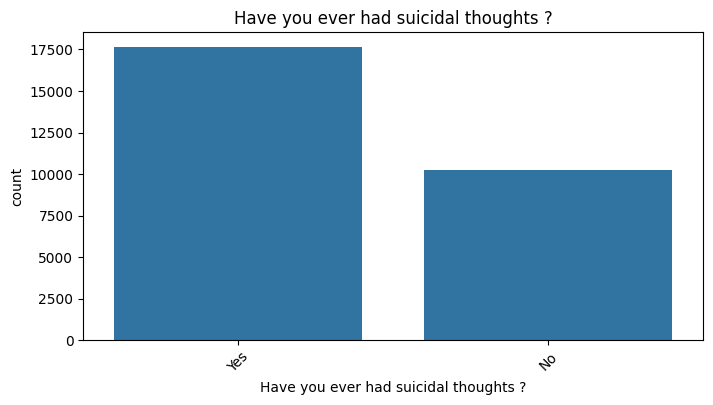

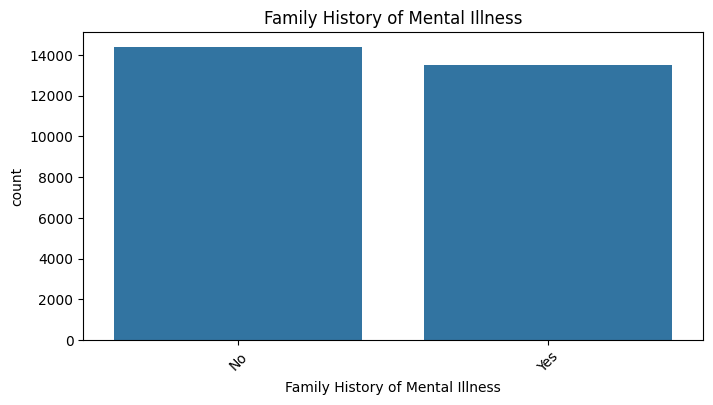

In [93]:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

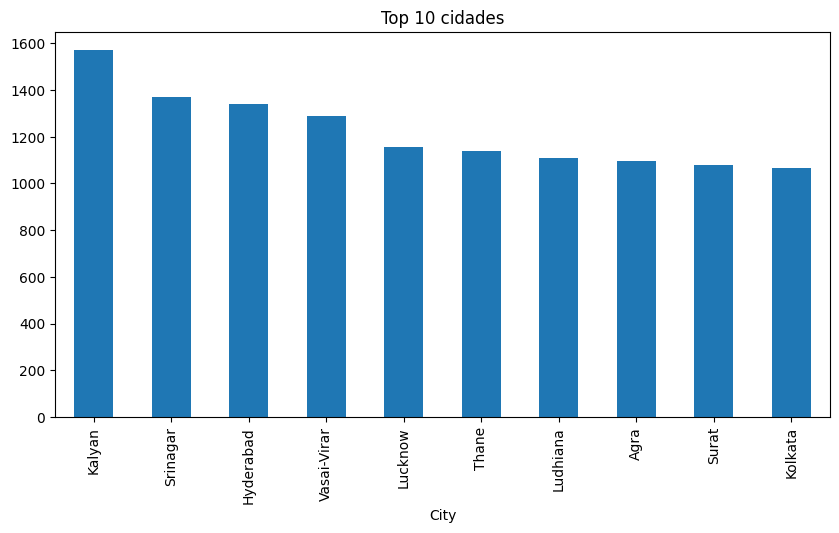

In [94]:
plt.figure(figsize=(10,5))

df['City'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 cidades')
plt.show()

### 3.1.3 - Variável alvo

Depression
1    16336
0    11565
Name: count, dtype: int64


Depression
1    58.55
0    41.45
Name: proportion, dtype: float64


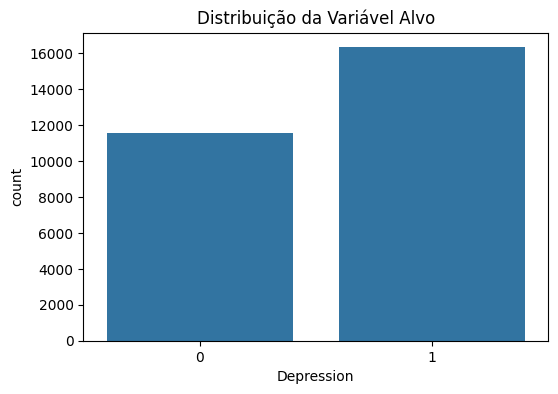

In [95]:
target = 'Depression'

print(df[target].value_counts())

print('\n')

print(round(df[target].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=target
)

plt.title('Distribuição da Variável Alvo')
plt.show()


## 3.2 Visão Cruzada (Análise Bivariada)

Nesta etapa, as variáveis do dataset foram cruzadas para entender como elas interagem entre si e como elas afetam a nossa variável preditiva (`Depression`). A análise será dividida em quatro frentes:
1. **Numérica x Numérica:** Buscando correlações lineares ou agrupamentos.
2. **Numérica x Categórica:** Avaliando como as distribuições numéricas mudam dentro de cada grupo.
3. **Categórica x Categórica:** Verificando a frequência conjunta de categorias.
4. **Variáveis x Target:** O passo importante para identificar quais features têm maior peso indicativo sobre a depressão dos estudantes.

### 3.2.1 - Numérica x numérica

Cruzamento: Numérica x Numérica


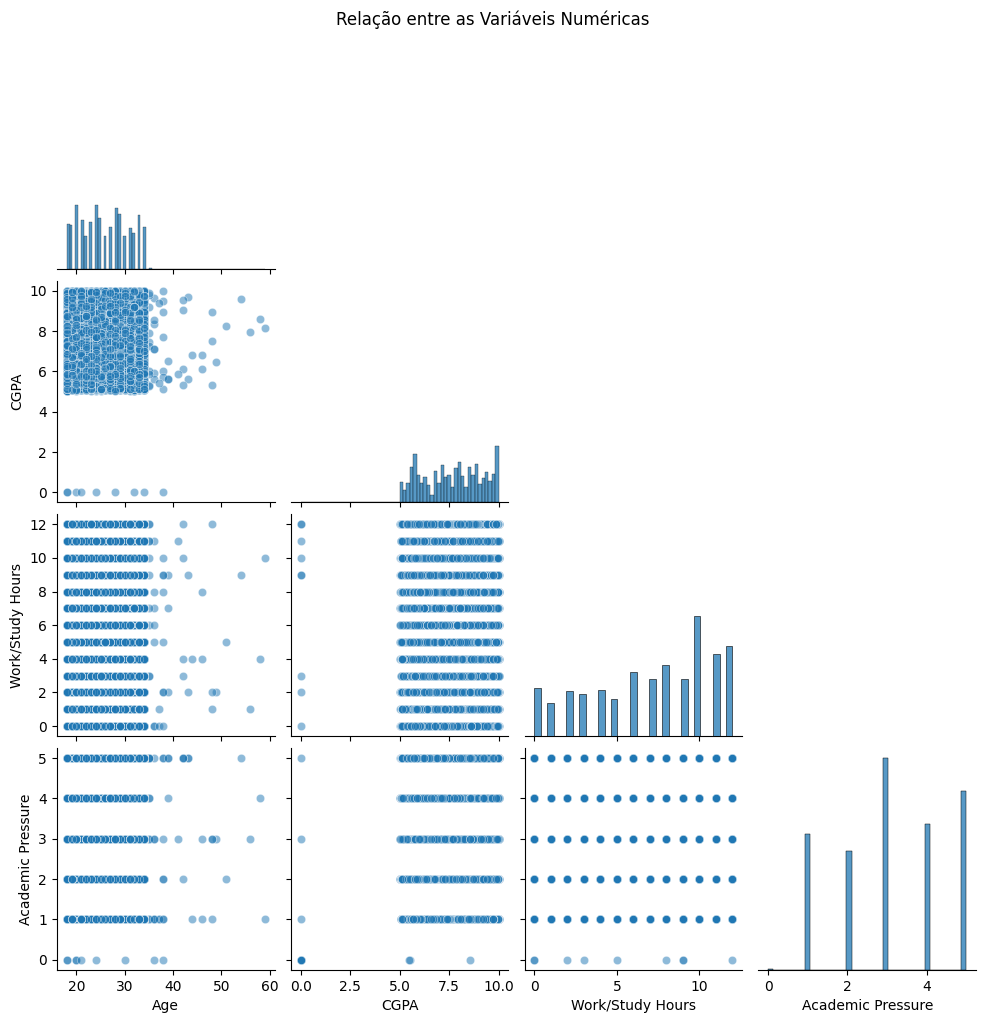

In [96]:
print("Cruzamento: Numérica x Numérica")
num_cols_principais = ['Age', 'CGPA', 'Work/Study Hours', 'Academic Pressure']

# O pairplot gera gráficos de dispersão (scatterplots) combinando todas as numéricas
sns.pairplot(df[num_cols_principais], corner=True, plot_kws={'alpha':0.5})
plt.suptitle('Relação entre as Variáveis Numéricas', y=1.02)
plt.show()

### 3.2.2 - Numérica x categórica

Cruzamento: Numérica x Categórica


/tmp/ipykernel_467/4277587363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Duration', y='CGPA', palette='Set2')
/tmp/ipykernel_467/4277587363.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Duration', y='Work/Study Hours', palette='Set2')


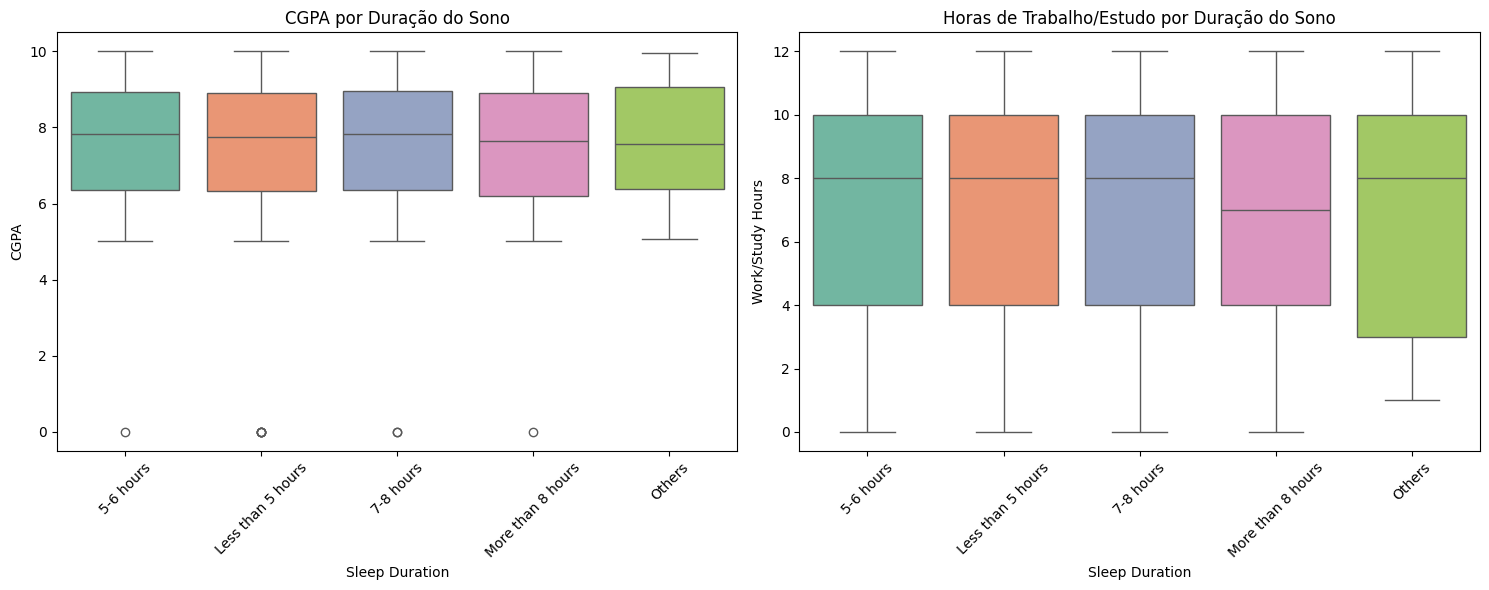

In [97]:
# 9.2 Numérica x Categórica
print("Cruzamento: Numérica x Categórica")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Sleep Duration', y='CGPA', palette='Set2')
plt.title('CGPA por Duração do Sono')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Sleep Duration', y='Work/Study Hours', palette='Set2')
plt.title('Horas de Trabalho/Estudo por Duração do Sono')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.2.3 - Categórica x categórica

Cruzamento: Categórica x Categórica


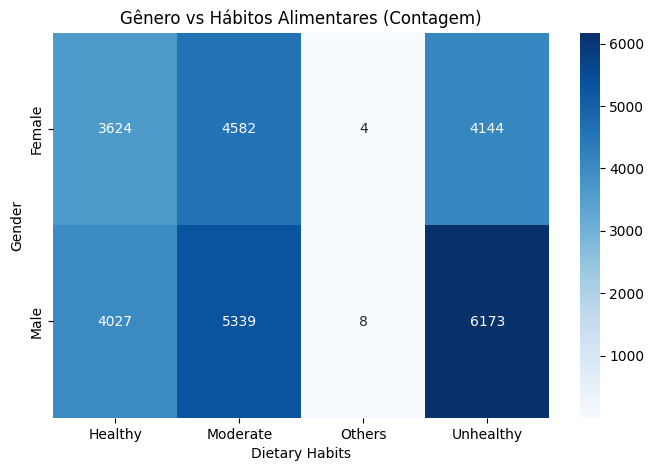

In [98]:
print("Cruzamento: Categórica x Categórica")

crosstab_cat = pd.crosstab(df['Gender'], df['Dietary Habits'])

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_cat, annot=True, fmt='d', cmap='Blues')
plt.title('Gênero vs Hábitos Alimentares (Contagem)')
plt.show()

### 3.2.4 - Variáveis x target

Cruzamento: Variáveis x Target (Depressão)


/tmp/ipykernel_467/3166731437.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y='Academic Pressure', palette='Set1')
/tmp/ipykernel_467/3166731437.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y='CGPA', palette='Set1')


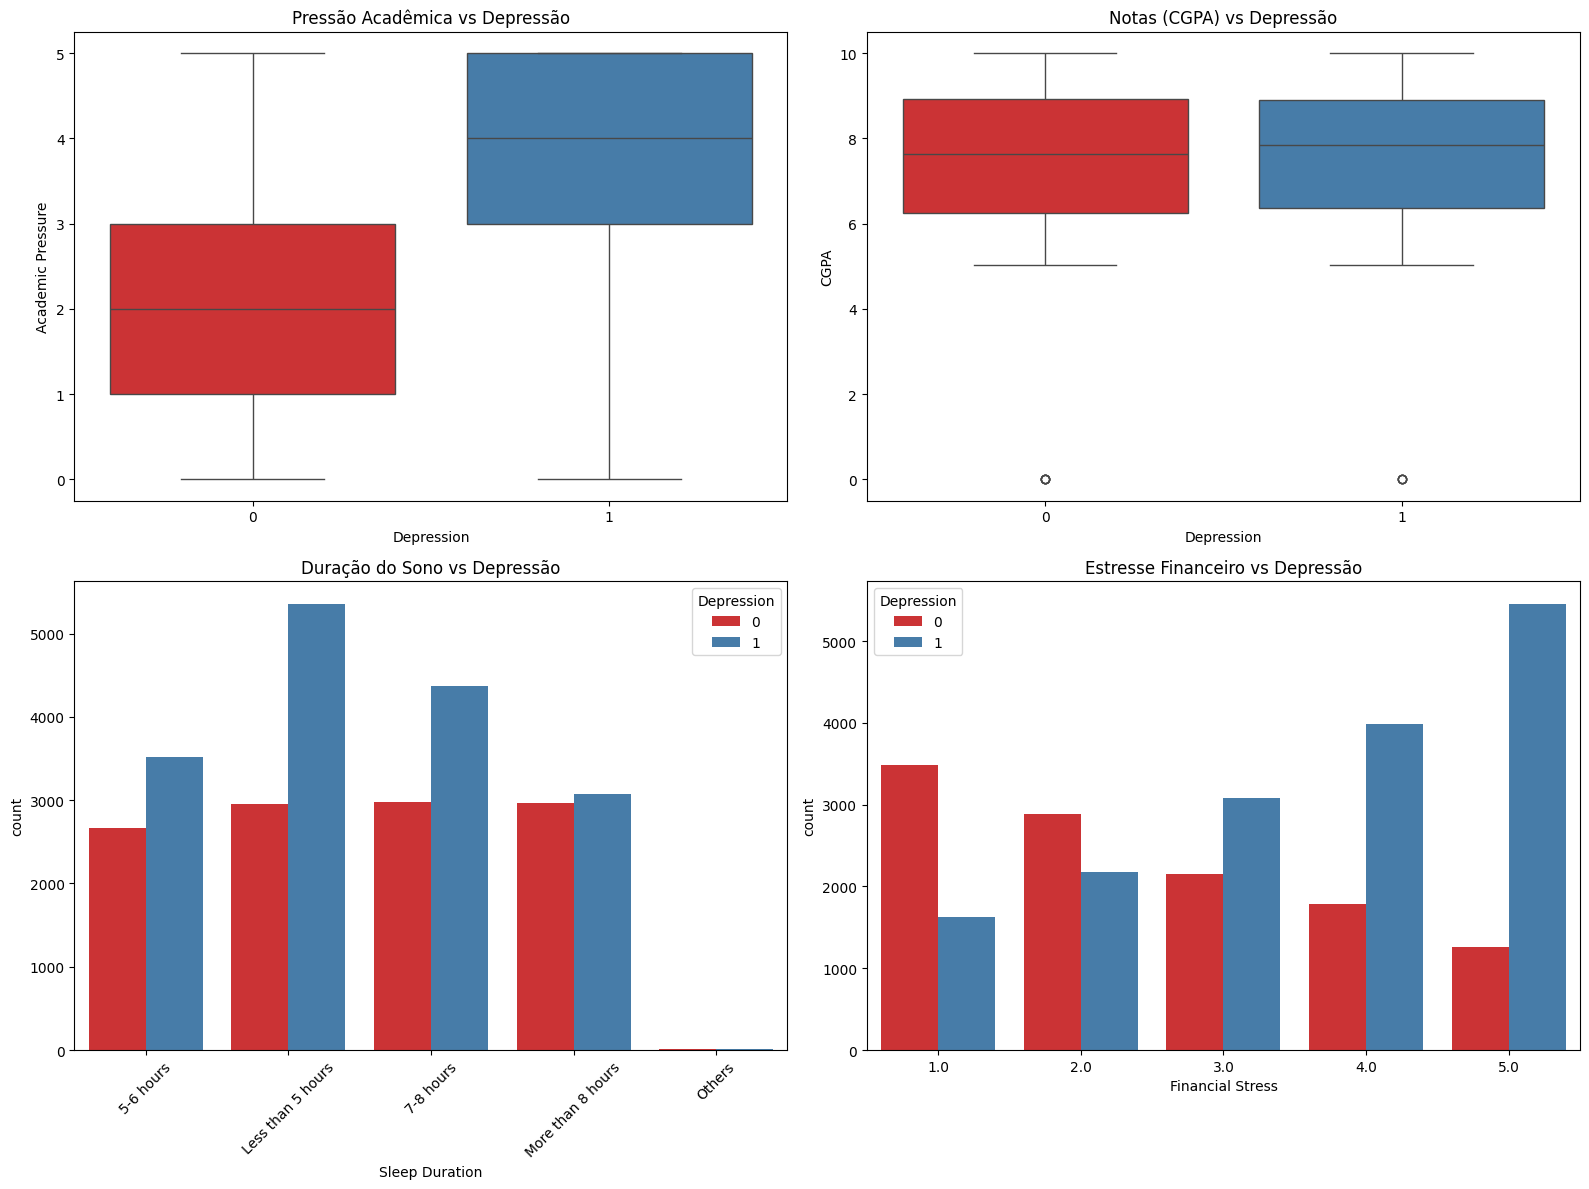

In [99]:
print("Cruzamento: Variáveis x Target (Depressão)")

plt.figure(figsize=(16, 12))

# Numérica vs Target
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Depression', y='Academic Pressure', palette='Set1')
plt.title('Pressão Acadêmica vs Depressão')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Depression', y='CGPA', palette='Set1')
plt.title('Notas (CGPA) vs Depressão')

# Categórica vs Target
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Sleep Duration', hue='Depression', palette='Set1')
plt.title('Duração do Sono vs Depressão')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Financial Stress', hue='Depression', palette='Set1')
plt.title('Estresse Financeiro vs Depressão')

plt.tight_layout()
plt.show()

## 3.4 Visão Global (Correlações e Vazamento)

Mapa de Correlação (Pearson):



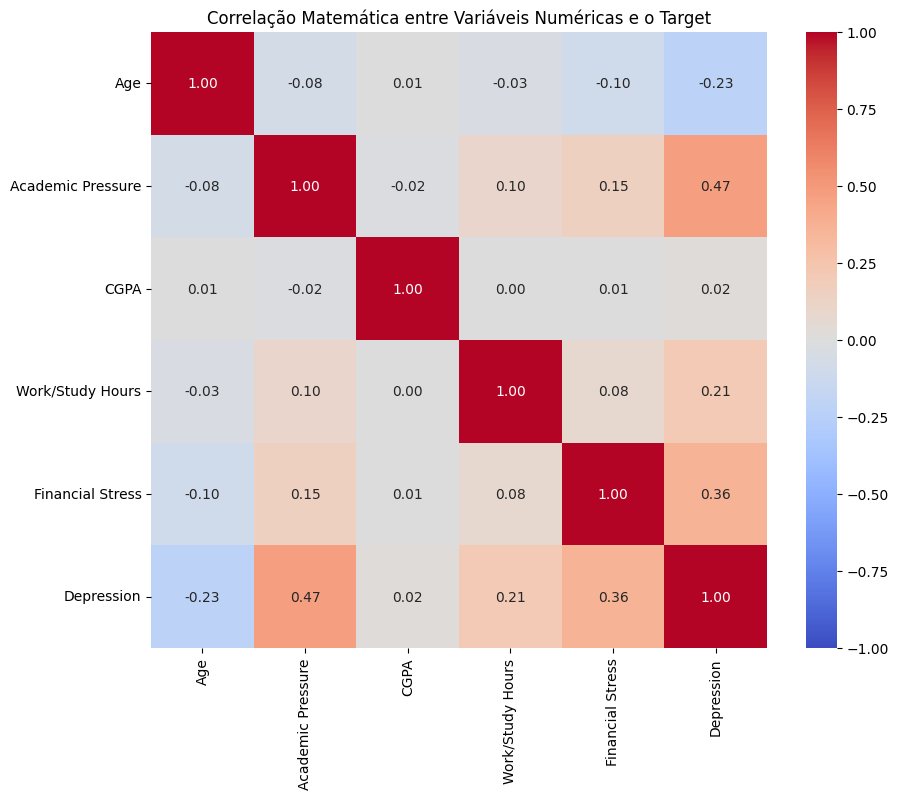


Top variáveis correlacionadas com a Depressão:
Depression           1.000000
Academic Pressure    0.474835
Financial Stress     0.363591
Work/Study Hours     0.208563
CGPA                 0.022210
Age                 -0.226422
Name: Depression, dtype: float64


In [100]:
print("Mapa de Correlação (Pearson):\n")

cols_corr = ['Age', 'Academic Pressure', 'CGPA', 'Work/Study Hours', 'Financial Stress', 'Depression']
matriz_correlacao = df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title('Correlação Matemática entre Variáveis Numéricas e o Target')
plt.show()

print("\nTop variáveis correlacionadas com a Depressão:")
print(matriz_correlacao['Depression'].sort_values(ascending=False))

### 3.4.2 - Variáveis Redundantes

Avaliando a matriz de correlação, foi observado o relacionamento entre as variáveis numéricas independentes:
* **Ausência de Redundância:** Como verificado nos cruzamentos das features, não há indícios de multicolinearidade. Nenhuma variável numérica apresenta correlação extrema entre si.
* **Conclusão:** Cada variável traz uma informação matemática única. Portanto, nenhuma coluna numérica precisará ser descartada por redundância.

### 3.4.3 - Vazamento de Dados (Data Leakage):

* **Análise Matemática:** A correlação máxima com a variável alvo (`Depression`) foi de **0.47** (Pressão Acadêmica). Por estar longe de 1.0, está totalmente descartada a hipótese de vazamento de dados direto nas variáveis numéricas.
* **Análise Lógica (Alerta Categórico):** Ressaltamos que a variável categórica `Have you ever had suicidal thoughts ?` requer atenção. Por ser um sintoma clínico direto da depressão, incluí-la no modelo pode causar target leakage. Isso torna o modelo capaz de "identificar" a depressão apenas pela presença do sintoma, e não pelos fatores de risco, o que compromete sua utilidade para um diagnóstico precoce.

### Principais Preditores Numéricos
Os fatores que mais pesam no diagnóstico neste dataset são:
1. **Pressão Acadêmica** (Correlação de **0.47**)
2. **Estresse Financeiro** (Correlação de **0.36**)
3. **Idade** (Correlação de **-0.23**): Mostra uma leve tendência inversa, indicando que estudantes mais jovens tendem a relatar mais os quadros de depressão.

As variáveis puramente de desempenho acadêmico, como as notas/CGPA (0.02), demonstraram impacto estatístico praticamente nulo no diagnóstico.

# 4 - Preparação para o Modelo

## 4.1 - Feature Engineering inicial

### 4.1.1 - Transformações e Encoding

**VARIÁVEIS BINÁRIAS**

Label Encoding: `object` -> `int64`

In [101]:
print("Antes:")
print(df[[
    "Gender",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]].head())


df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

df["Have you ever had suicidal thoughts ?"] = df[
    "Have you ever had suicidal thoughts ?"
].map({
    "No": 0,
    "Yes": 1
})

df["Family History of Mental Illness"] = df[
    "Family History of Mental Illness"
].map({
    "No": 0,
    "Yes": 1
})

print("\nDepois:")
print(df[[
    "Gender",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]].head())

Antes:
   Gender Have you ever had suicidal thoughts ?  \
0    Male                                   Yes   
1  Female                                    No   
2    Male                                    No   
3  Female                                   Yes   
4  Female                                   Yes   

  Family History of Mental Illness  
0                               No  
1                              Yes  
2                              Yes  
3                              Yes  
4                               No  

Depois:
   Gender  Have you ever had suicidal thoughts ?  \
0       0                                      1   
1       1                                      0   
2       0                                      0   
3       1                                      1   
4       1                                      1   

   Family History of Mental Illness  
0                                 0  
1                                 1  
2                           

**VARIÁVEIS ORDINAIS**

Ordinal Encoding:
`object` -> `float64`


In [102]:
sleep_map = {
    "Less than 5 hours": 0,
    "5-6 hours": 1,
    "7-8 hours": 2,
    "More than 8 hours": 3,
    "Others": np.nan
}

df["Sleep Duration"] = df["Sleep Duration"].map(sleep_map)

print(df["Sleep Duration"].unique())
print(df["Sleep Duration"].dtype)

diet_map = {
    "Unhealthy": 0,
    "Moderate": 1,
    "Healthy": 2,
    "Others": np.nan
}

df["Dietary Habits"] = df["Dietary Habits"].map(diet_map)

print(df["Dietary Habits"].unique())
print(df["Dietary Habits"].dtype)

[ 1.  0.  2.  3. nan]
float64
[ 2.  1.  0. nan]
float64


**VARIÁVEIS NOMINAIS**

One-Hot Encoding

In [103]:
df = pd.get_dummies(df, columns=["Degree"], drop_first=True)
print(df.dtypes)

id                                         int64
Gender                                     int64
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                           float64
Dietary Habits                           float64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                                 int64
Degree_B.Com                                bool
Degree_B.Ed                                 bool
Degree_B.Pharm                              bool
Degree_B.Tech       

Embora a variável City possua um grande número de categorias, optou-se por mantê-la temporariamente para análises posteriores. Essa decisão permite avaliar sua relevância para a predição da depressão e evitar a exclusão prematura de uma informação que possa contribuir para a identificação de padrões no conjunto de dados. Caso a variável seja mantida nas etapas de modelagem, será necessária a aplicação de técnicas de codificação para variáveis categóricas, como o One-Hot Encoding.

**REMOÇÃO DE VARIÁVEIS**

Considerando que o objetivo do estudo é investigar fatores associados à depressão em estudantes, foram mantidos apenas os registros cuja profissão era classificada como Student. Essa filtragem resultou na remoção de 31 registros (0,11% do conjunto de dados), correspondentes a outras ocupações. Em seguida, a variável Profession foi removida, uma vez que passou a apresentar um único valor para todas as observações restantes, não agregando informação relevante para a análise.

In [104]:
df = df[df["Profession"] == "Student"]
print(df.shape)

df.drop(columns=["Profession"], inplace=True)
print(df.shape)

(27870, 44)
(27870, 43)


As variáveis Work Pressure e Job Satisfaction foram removidas após a seleção exclusiva de estudantes, pois apresentaram variabilidade praticamente nula (mais de 99% dos registros concentrados no valor zero).

In [105]:
df.drop(
    columns=["Work Pressure", "Job Satisfaction"],
    inplace=True
)

print(df.shape)
print(df.columns.tolist())

(27870, 41)
['id', 'Gender', 'Age', 'City', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Degree_B.Com', 'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BA', 'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc', 'Degree_Class 12', 'Degree_LLB', 'Degree_LLM', 'Degree_M.Com', 'Degree_M.Ed', 'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA', 'Degree_MBA', 'Degree_MBBS', 'Degree_MCA', 'Degree_MD', 'Degree_ME', 'Degree_MHM', 'Degree_MSc', 'Degree_Others', 'Degree_PhD']


###  4.1.2 - Criação de variáveis derivadas

A criação de variáveis derivadas foi orientada pelos resultados da análise exploratória e do estudo de correlação. As variáveis **Academic Pressure** (correlação de 0,475 com a variável alvo) e **Financial Stress** (correlação de 0,364) apresentaram as associações mais relevantes com a ocorrência de depressão. Além disso, observou-se um aumento consistente da proporção de estudantes com depressão nos níveis mais elevados dessas variáveis. Dessa forma, foram criados os atributos **High_Academic_Pressure** e **High_Financial_Stress**, com o objetivo de representar de forma mais direta estudantes submetidos a altos níveis de pressão acadêmica e estresse financeiro.

In [106]:
# High_Academic_Pressure
df["High_Academic_Pressure"] = (
    df["Academic Pressure"] >= 4
).astype(int)

print(df["High_Academic_Pressure"].value_counts())

# High_Financial_Stress
df["High_Financial_Stress"] = (
    df["Financial Stress"] >= 4
).astype(int)

print(df["High_Financial_Stress"].value_counts())

print(df[[
    "High_Financial_Stress",
    "High_Academic_Pressure"
]].head())

print(df[[
    "High_Financial_Stress",
    "High_Academic_Pressure"
]].dtypes)

High_Academic_Pressure
0    16434
1    11436
Name: count, dtype: int64
High_Financial_Stress
0    15396
1    12474
Name: count, dtype: int64
   High_Financial_Stress  High_Academic_Pressure
0                      0                       1
1                      0                       0
2                      0                       0
3                      1                       0
4                      0                       1
High_Financial_Stress     int64
High_Academic_Pressure    int64
dtype: object


## 4.2 - Sugestão de pré-processamento

###  4.2.1 - Tratamento definitivo de missing e outliers

Variáveis que apresentam valores ausentes devem ser tratadas antes da modelagem. A estrategia pode variar com o tipo da variável tratada.

#### **Variáveis Numéricas**

Para variáveis numéricas, a abordagem recomendada é a substituição dos valores ausentes pela **mediana**. Essa medida é menos sensível à presença de valores extremos do que a média aritmética, preservando melhor a distribuição original dos dados.

#### **Variáveis Categóricas**

Para variáveis categóricas, recomenda-se a substituição pela **categoria mais frequente (moda)**. Alternativamente, pode-se criar uma nova categoria para representar valores ausentes quando essa ausência puder conter informação relevante para a análise.

In [107]:
# Quantidade e percentual de valores ausentes

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Quantidade': missing_count,
    'Percentual (%)': missing_percent
})

missing_df = missing_df[missing_df['Quantidade'] > 0]
missing_df.sort_values('Percentual (%)', ascending=False)

,Quantidade,Percentual (%)
Sleep Duration,18,0.064586
Dietary Habits,12,0.043057
Financial Stress,3,0.010764


In [108]:
# Preenchimento pela mediana

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [109]:
# Preenchimento pela moda

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Em relação aos outliers, a análise exploratória indicou que algumas variáveis apresentam observações extremas. Como esses valores podem representar características reais dos estudantes e não erros de coleta, recomenda-se avaliar seu impacto no desempenho dos modelos antes de optar pela remoção.

In [110]:
# Identificação de outliers usando IQR

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'{col}: {len(outliers)} outliers')

id: 0 outliers
Gender: 0 outliers
Age: 12 outliers
Academic Pressure: 0 outliers
CGPA: 9 outliers
Study Satisfaction: 0 outliers
Sleep Duration: 0 outliers
Dietary Habits: 0 outliers
Have you ever had suicidal thoughts ?: 0 outliers
Work/Study Hours: 0 outliers
Financial Stress: 0 outliers
Family History of Mental Illness: 0 outliers
Depression: 0 outliers
High_Academic_Pressure: 0 outliers
High_Financial_Stress: 0 outliers


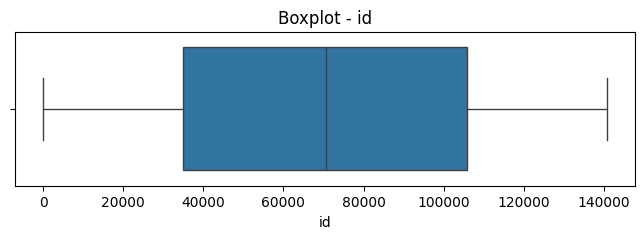

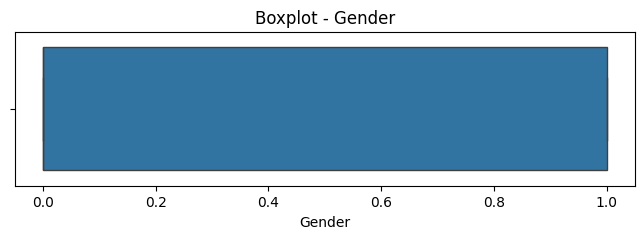

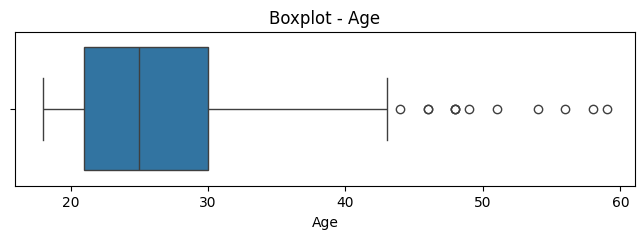

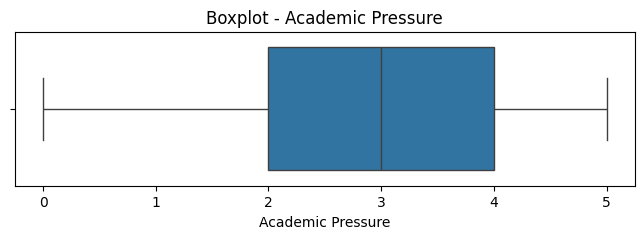

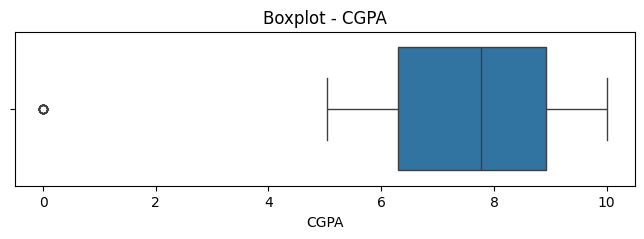

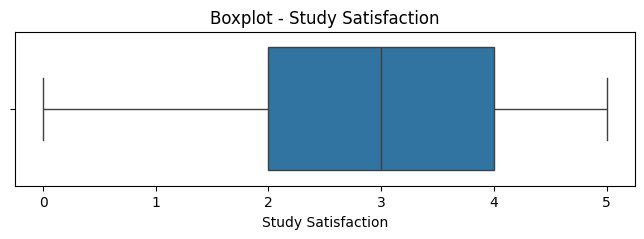

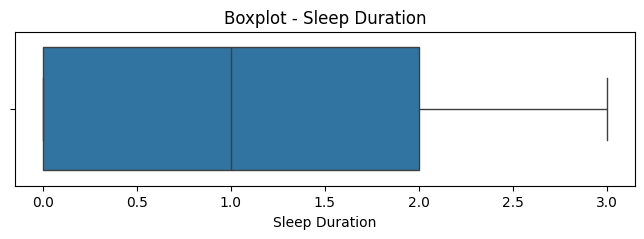

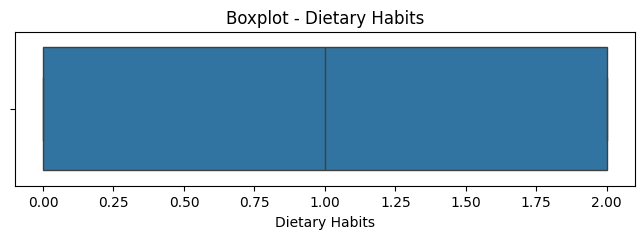

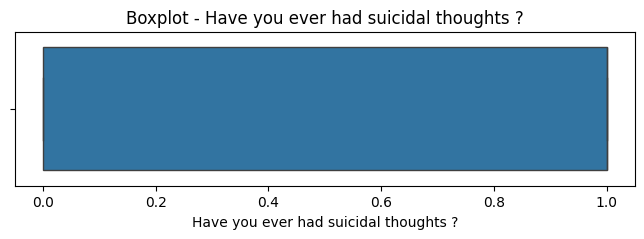

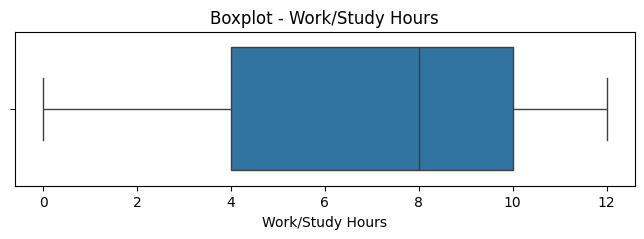

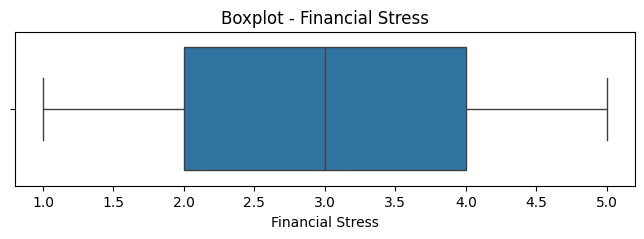

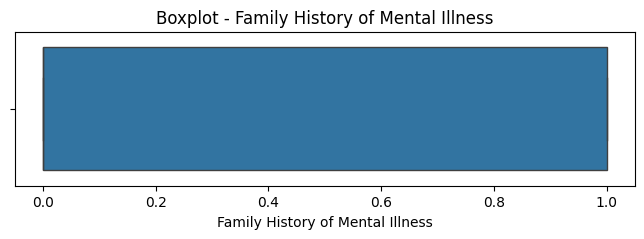

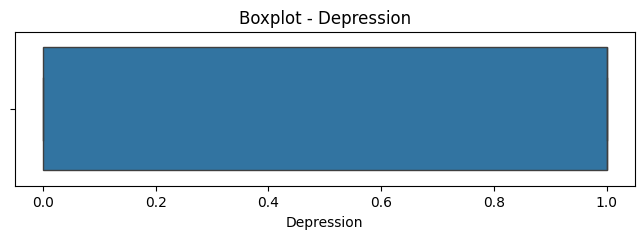

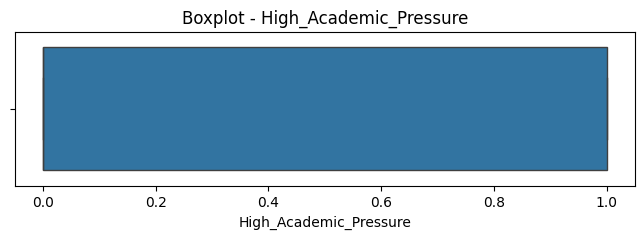

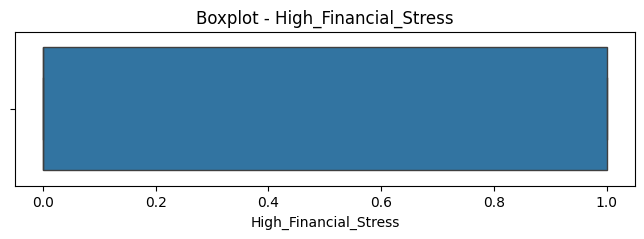

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

###  4.2.2 - Normalização/padronização

As variáveis numéricas possuem escalas distintas, podendo influenciar no peso de uma variável em detrimento de outra, o ideal é realizar um tratamento de normalização utilizando técnicas de padronização ou normalização

#### **Padronização (Standardization)**

A padronização transforma os dados de modo que apresentem média igual a 0 e desvio padrão igual a 1. Essa técnica é amplamente utilizada em algoritmos que dependem de distância ou otimização matemática, como Regressão Logística, SVM e KNN.

#### **Normalização (Min-Max Scaling)**

A normalização ajusta os valores para um intervalo fixo, geralmente entre 0 e 1. Essa abordagem preserva a relação proporcional entre os dados e é útil quando se deseja limitar a amplitude das variáveis.

In [112]:
from sklearn.preprocessing import StandardScaler

# Seleciona apenas colunas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Cria uma cópia do dataset
df_standardized = df.copy()

# Aplica a padronização
scaler = StandardScaler()
df_standardized[numeric_cols] = scaler.fit_transform(df_standardized[numeric_cols])

df_standardized[numeric_cols].head()

,id,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,High_Academic_Pressure,High_Financial_Stress
0,-1.733521,-0.891463,1.463138,1.345804,0.893367,-0.693190,-0.353736,1.375338,0.762062,-1.121613,-1.488676,-0.968282,0.842008,1.198766,-0.900117
1,-1.733374,1.121751,-0.371169,-0.825568,-1.193920,1.510772,-0.353736,0.120241,-1.312229,-1.121613,-0.792872,1.032757,-1.187637,-0.834191,-0.900117
2,-1.732931,-0.891463,1.055514,-0.101777,-0.425635,1.510772,-1.241582,1.375338,-1.312229,0.496897,-1.488676,1.032757,-1.187637,-0.834191,-0.900117
3,-1.732832,1.121751,0.444079,-0.101777,-1.404688,-0.693190,0.534109,0.120241,0.762062,-0.851862,1.294540,1.032757,0.842008,-0.834191,1.110967
4,-1.732783,1.121751,-0.167357,0.622013,0.322253,0.041464,-0.353736,0.120241,0.762062,-1.661117,-1.488676,-0.968282,-1.187637,1.198766,-0.900117


In [113]:
from sklearn.preprocessing import MinMaxScaler

# Seleciona apenas colunas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Cria uma cópia do dataset
df_normalized = df.copy()

# Aplica a normalização
scaler = MinMaxScaler()
df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

df_normalized[numeric_cols].head()

,id,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,High_Academic_Pressure,High_Financial_Stress
0,0.000000,0.0,0.365854,1.0,0.897,0.4,0.333333,1.0,1.0,0.250000,0.00,0.0,1.0,1.0,0.0
1,0.000043,1.0,0.146341,0.4,0.590,1.0,0.333333,0.5,0.0,0.250000,0.25,1.0,0.0,0.0,0.0
2,0.000171,0.0,0.317073,0.6,0.703,1.0,0.000000,1.0,0.0,0.750000,0.00,1.0,0.0,0.0,0.0
3,0.000199,1.0,0.243902,0.6,0.559,0.4,0.666667,0.5,1.0,0.333333,1.00,1.0,1.0,0.0,1.0
4,0.000213,1.0,0.170732,0.8,0.813,0.6,0.333333,0.5,1.0,0.083333,0.00,0.0,0.0,1.0,0.0


###  4.2.3 - Remoção de colunas irrelevantes

Nem todas as variáveis presentes no conjunto de dados contribuem de forma significativa para a construção de modelos preditivos. Variáveis com baixa variabilidade, informações redundantes, identificadores únicos ou atributos sem relação com a variável alvo podem aumentar a complexidade do modelo sem gerar ganhos de desempenho.

Dessa forma, recomenda-se a análise das variáveis com base em critérios como correlação, importância das features e conhecimento do domínio do problema. A remoção desses atributos pode reduzir a dimensionalidade do conjunto de dados, diminuir o custo computacional e melhorar a capacidade de generalização dos modelos.


In [114]:
# Colunas sem variabilidade

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print("Colunas sem variabilidade:")
print(constant_cols)

Colunas sem variabilidade:
[]


In [115]:
# Correlação das variáveis numéricas com a variável alvo(depression neste caso)

corr_target = (
    df.select_dtypes(include=['int64', 'float64'])
      .corr()['Depression']
      .sort_values(key=abs, ascending=False)
)

corr_target

,Depression
Depression,1.000000
Have you ever had suicidal thoughts ?,0.546434
Academic Pressure,0.474805
High_Academic_Pressure,0.390748
Financial Stress,0.363672
High_Financial_Stress,0.312526
Age,-0.226738
Work/Study Hours,0.209024
Dietary Habits,-0.206906
Study Satisfaction,-0.168132


In [116]:
# Removendo colunas consideradas irrelevantes

cols_to_drop = [
    'id',      # identificador
    'Name'     # caso exista
]

df_reduced = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colunas restantes: {df_reduced.shape[1]}")

Colunas restantes: 42


# 5. Conclusões do Estudo

Esta seção sintetiza os principais ponttos obtidos ao longo da análise exploratória e do pipeline de preparação dos dados, fornecendo os dados necessários tanto para o entendimento do problema quanto para as próximas etapas de modelagem preditiva.

## 5.1 - Insights encontrados

A análise exploratória permitiu identificar padrões relevantes associados à ocorrência de depressão entre estudantes.



*   Altos níveis de pressão acadêmica aumentam significativamente a probabilidade de depressão.

Entre todas as variáveis numéricas examinadas, a Pressão Acadêmica apresentou a maior correlação linear positiva com a depressão (0.47). O aumento dos níveis desse indicador está diretamente associado a uma maior proporção de estudantes diagnosticados.

*  O estresse financeiro contribui para o agravamento da saúde mental dos estudantes.

O Estresse Financeiro surge como o segundo preditor numérico mais relevante (correlação de 0.36). Isso valida que as demandas econômicas exercem um peso psicológico significativo sobre a saúde mental do corpo discente.

* Estudantes mais jovens apresentam maior suscetibilidade à depressão.

A Idade apresentou uma correlação negativa (-0.23). Esse comportamento indica que, dentro do intervalo de 18 a 59 anos presente no dataset, os estudantes mais jovens (próximos à média de 25,8 anos) possuem uma tendência estatisticamente maior de relatar quadros depressivos.

*  Notas mais altas ou mais baixas não parecem estar diretamente associadas à ocorrência de depressão.

Ao contrário do senso comum, a média de notas (CGPA) demonstrou uma correlação praticamente nula (0.02) com a depressão. Isso prova que o desempenho acadêmico isolado não é um indicador de bem-estar ou sofrimento psíquico neste grupo.

*  Pensamentos suicidas podem atuar como um forte indicador de quadros depressivos.

A variável categórica Have you ever had suicidal thoughts ? possui uma relação fortíssima com o público diagnosticado, operando quase como um indicador direto do estado avançado da condição.

## 5.2 - Hipóteses geradas

Hipótese 1 : A maior incidência de depressão em estudantes mais jovens pode estar associada às dificuldades de transição para o ensino superior, falta de rede de apoio local nas novas cidades e imaturidade no manejo de crises.

Hipótese 2 : Existe um efeito crítico onde níveis de Pressão Acadêmica e Estresse Financeiro iguais ou superiores a 4 acionam uma probabilidade exponencialmente maior de desenvolvimento da depressão. As variáveis derivadas *High_Academic_Pressure* e *High_Financial_Stress* criadas na engenharia de atributos devem se provar os preditores mais fortes nos modelos de árvore.

Hipótese 3 : A duração do sono inferior a 5 horas não é apenas um sintoma, mas um fator mediador que amplifica o impacto da Pressão Acadêmica no desenvolvimento de transtornos psicológicos.

## 5.3 - Limitações do Dataset

Apesar da boa qualidade geral dos dados, algumas limitações devem ser consideradas durante a interpretação dos resultados e o desenvolvimento dos modelos.

* **Vazamento Potencial de Conceito (Target Leakage):** A variável *Have you ever had suicidal thoughts ?* é clinicamente um sintoma grave do próprio quadro depressivo. Mantê-la no modelo pode inflar artificialmente a acurácia do algoritmo, gerando um modelo que não previne a depressão, mas apenas identifica quando ela já está em estágio crítico.

* **Presença de Ruído na Coleta de Dados:** A coluna City apresentou sérias inconsistências de inputting, como a mistura de nomes próprios como "Saanvi", siglas de cursos como "M.Tech" e erros de digitação como "Khaziabad". Gerando a necessidade de uma limpeza manual.

* **Falta de Contexto Socioeconômico Detalhado:** Embora o dataset avalie o "Estresse Financeiro" em uma escala ordinal de 1 a 5, não há dados objetivos sobre renda familiar, recebimento de bolsas de estudo ou se o estudante precisa conciliar o curso com um emprego formal.

* **Viés de Amostragem Original:** O dataset continha registros de profissões variadas (como Chef, Arquiteto, etc.) infiltrados em um conjunto nominalmente voltado para estudantes. Embora tenham sido filtrados e removidos (31 registros), isso aponta para possíveis fragilidades no controle de qualidade da coleta original no Kaggle.

Além disso, algumas variáveis são baseadas em autorrelato dos participantes, o que pode introduzir vieses de percepção, memória ou desejabilidade social, afetando a precisão das respostas fornecidas.

Por fim, os dados foram obtidos a partir de uma única fonte pública e podem não representar adequadamente todos os perfis de estudantes, limitando a capacidade de generalização dos resultados para outras populações, regiões geográficas ou contextos educacionais.